# **PART 1: Data Cleaning and Exploratory Data Analysis (EDA)**


## 0. Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

BRAND_COLORS = {
    'CHANEL':        '#1a1a1a',
    'HERMES':        '#E8571A',
    'DIOR':          '#B5A99A',
    'LOUIS_VUITTON': '#8B6914'
}


## 1. Loading and initial inspection

In [34]:
FILE_PATH = 'resale_listings.csv'

df_raw = pd.read_csv(FILE_PATH, sep=';', on_bad_lines='skip')

print(f'Dimensiones: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
df_raw.head(3)

Dimensiones: 302 filas × 30 columnas


,row_id,platform,snapchot_date,listing_url,listing_id_platform,currency,discount_flag,price_was,price_current,title_raw,...,condition_raw,wear_notes,platform_authentification_flag,includes_dustbag,includes_box,includes_card_of_certificate,availability_status,serial_number_raw,product_key_core,product_key_extended
0,R_000001,Farfetch,2026-02-14,https://www.farfetch.com/es/shopping/women/cha...,23968984,EUR,0,NaN,6419,Chanel Pre-Owned 2000 mini square Classic Flap...,...,Good,This previously owned and used item is in good...,1,UNKNOWN,UNKNOWN,1,AVAILABLE,6634910,CHANEL_CLASSIC_FLAP_MINI_SQUARE_SATIN,CHANEL_CLASSIC_FLAP_MINI_SQUARE_SATIN_BLACK_GOLD
1,R_000002,Farfetch,2026-02-15,https://www.farfetch.com/es/shopping/women/cha...,26109415,EUR,0,NaN,7645,Chanel Pre-Owned 1998 Classic Flap shoulder bag,...,Good,This previously owned and used item is in good...,1,1,1,1,AVAILABLE,5063019,CHANEL_CLASSIC_FLAP_JUMBO_CAVIAR,CHANEL_CLASSIC_FLAP_JUMBO_CAVIAR_BEIGE_GOLD
2,R_000003,Farfetch,2026-02-15,https://www.farfetch.com/es/shopping/women/cha...,24515647,EUR,0,NaN,8343,Chanel Pre-Owned 1998 Classic Flap shoulder bag,...,Good,This previously owned and used item is in good...,1,UNKNOWN,UNKNOWN,1,AVAILABLE,5052165,CHANEL_CLASSIC_FLAP_JUMBO_CAVIAR,CHANEL_CLASSIC_FLAP_JUMBO_CAVIAR_BLACK_GOLD


In [35]:
df_raw.dtypes

,0
row_id,object
platform,object
snapchot_date,object
listing_url,object
listing_id_platform,object
currency,object
discount_flag,int64
price_was,float64
price_current,int64
title_raw,object


In [36]:
#Missing Values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
(
    pd.DataFrame({'Missing': missing, '% total': missing_pct})
    .query('Missing > 0')
    .sort_values('Missing', ascending=False)
)

,Missing,% total
price_was,272,90.1
model_variant,130,43.0
made_in_country,108,35.8
wear_notes,5,1.7


In [37]:
print('Brand distribution:')
print(df_raw['brand'].value_counts())
print()
print('Platforms:')
print(df_raw['platform'].value_counts())

Brand distribution:
brand
CHANEL           91
HERMES           87
DIOR             64
LOUIS_VUITTON    60
Name: count, dtype: int64

Platforms:
platform
Farfetch        197
The RealReal    105
Name: count, dtype: int64


---
## 2. Data Cleaning and Standardisation

We will work on a copy of the original dataframe to preserve the raw data.

In [38]:
df = df_raw.copy()

### 2.1 Target Variable: Price

In [39]:
df['price_current'] = pd.to_numeric(df['price_current'], errors='coerce')
df['price_was']     = pd.to_numeric(df['price_was'],     errors='coerce')

# Remove listings with no price
n_before = len(df)
df = df.dropna(subset=['price_current'])
print(f'Rows removed due to missing price: {n_before - len(df)}')

# Discount percentage
df['discount_pct'] = np.where(
    df['discount_flag'] == 1,
    ((df['price_was'] - df['price_current']) / df['price_was'] * 100).round(1),
    0.0
)

# Log-price distribution
df['log_price'] = np.log(df['price_current'])

print(f'\nPrice statistics (EUR):')
print(df['price_current'].describe().apply(lambda x: f'{x:,.0f}'))

Rows removed due to missing price: 0

Price statistics (EUR):
count       302
mean     11,522
std      12,103
min         770
25%       2,816
50%       6,394
75%      16,004
max      62,892
Name: price_current, dtype: object


### 2.2 General String Cleaning

In [40]:
# Remove residual whitespace from all text columns
STR_COLS = [
    'brand', 'model_family', 'model_variant', 'size_raw',
    'material_raw', 'color_raw', 'hardware_raw',
    'made_in_country', 'condition_raw', 'platform'
]
for col in STR_COLS:
    df[col] = df[col].astype(str).str.strip()

# Replace the string 'nan' introduced by astype with real NaN
for col in STR_COLS:
    df[col] = df[col].replace('nan', np.nan)

# Replace 'UNKNOWN' with NaN
UNKNOWN_COLS = [
    'includes_dustbag', 'includes_box',
    'includes_card_of_certificate', 'serial_number_raw', 'made_in_country'
]
for col in UNKNOWN_COLS:
    df[col] = df[col].replace('UNKNOWN', np.nan)

# Convert flags to numeric (0 / 1 / NaN)
FLAG_COLS = ['includes_dustbag', 'includes_box',
             'includes_card_of_certificate', 'discount_flag']
for col in FLAG_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop zero-variance columns
df = df.drop(columns=['platform_authentification_flag', 'availability_status'])

print('String cleaning completed.')

String cleaning completed.


### 2.3 Color: Normalization to Base Color

In [41]:
def normalize_color(color):
    if pd.isna(color):
        return np.nan
    color = color.strip()
    # Any value containing '/' implies more than one color
    if '/' in color:
        return 'Multicolor'

    corrections = {

        'Bubblegum Pink': 'Pink',
        'Fuchsia Pink':   'Pink',
        'Rose Pink':      'Pink',
        'Salmon Pink':    'Pink',
        'Peach Orange':   'Orange',
        'Indigo Blue':    'Blue',
        'Navy Blue':      'Blue',
        'Lime Green':     'Green',
        'Emeraude':       'Green',
        'Mustard Yellow': 'Yellow',
        'Chalk White':    'White',
        'Light Beige':    'Beige',
        'Grey Mist':      'Grey',
    }
    return corrections.get(color, color)

df['color_clean'] = df['color_raw'].apply(normalize_color)

print('color_clean distribution:')
print(df['color_clean'].value_counts())

color_clean distribution:
color_clean
Black         70
Blue          48
Brown         46
Multicolor    23
Red           22
Pink          21
White         17
Green         15
Orange        11
Beige          9
Grey           7
Yellow         6
Gold           2
Silver         2
Gray           1
Burgundy       1
Purple         1
Name: count, dtype: int64


In [42]:
# Group colors with fewer than 5 observations into 'Other'
color_counts = df['color_clean'].value_counts()
rare_colors = color_counts[color_counts < 5].index.tolist()
print(f'Colors grouped into Other: {rare_colors}')

df['color_clean'] = df['color_clean'].apply(
    lambda x: 'Other' if x in rare_colors else x
)

print(df['color_clean'].value_counts())

Colors grouped into Other: ['Gold', 'Silver', 'Gray', 'Burgundy', 'Purple']
color_clean
Black         70
Blue          48
Brown         46
Multicolor    23
Red           22
Pink          21
White         17
Green         15
Orange        11
Beige          9
Other          7
Grey           7
Yellow         6
Name: count, dtype: int64


### 2.4 Hardware: normalización

In [43]:
print('hardware_raw tras strip:', df['hardware_raw'].value_counts(dropna=False).to_dict())

hardware_raw tras strip: {'Gold': 214, 'Silver': 88}


### 2.5 Condition: Ordinal Numeric Scale

In [44]:
CONDITION_MAP = {
    'As Is':     1,
    'Fair':      2,
    'Good':      3,
    'Very Good': 4,
    'Excellent': 5,
    'Pristine':  6,
    'Unused':    6,
    'Unknown':   np.nan
}

df['condition_score'] = df['condition_raw'].map(CONDITION_MAP)

print('condition_score distribution:')
print(df['condition_score'].value_counts(dropna=False).sort_index())

condition_score distribution:
condition_score
1.0      5
2.0      2
3.0    157
4.0     35
5.0     84
6.0     14
NaN      5
Name: count, dtype: int64


In [45]:
# Drop the 5 listings with condition_raw = 'Unknown'

df = df[df['condition_score'].notna()].reset_index(drop=True)
print(f'Registros tras eliminar unknowns de condición: {len(df)} — eliminados: {302 - len(df)}')

Registros tras eliminar unknowns de condición: 297 — eliminados: 5


### 2.6 Bag Year and Age

In [46]:
SNAPSHOT_YEAR = 2026

import math

def parse_year(val):
    val = str(val).strip()
    if '-' in val:
        parts = val.split('-')
        try:
            return math.floor(sum(int(p) for p in parts) / len(parts) + 0.5)
        except ValueError:
            return np.nan
    try:
        return int(val)
    except ValueError:
        return np.nan

df['year_clean'] = df['year_raw'].apply(parse_year)

# Sanity check: years outside the plausible range
mask_invalid = (df['year_clean'] < 1950) | (df['year_clean'] > SNAPSHOT_YEAR)
if mask_invalid.sum() > 0:
    print(f'Invalid years: {df.loc[mask_invalid, "year_clean"].unique()} → NaN')
    df.loc[mask_invalid, 'year_clean'] = np.nan
else:
    print('No years outside range.')

# Verify the ranges that existed
rangos = df[df['year_raw'].astype(str).str.contains('-', na=False)][['year_raw','year_clean']]
print(f'\nYear ranges converted ({len(rangos)} cases):')
print(rangos.drop_duplicates().to_string(index=False))

# 'age' = years from manufacture to snapshot
df['age'] = SNAPSHOT_YEAR - df['year_clean']

print(f'\nMean age: {df["age"].mean():.1f} years')
print(f'Age range: {df["age"].min():.0f} — {df["age"].max():.0f} years')
print(f'Nulls in year_clean: {df["year_clean"].isnull().sum()}')

No years outside range.

Year ranges converted (16 cases):
 year_raw  year_clean
2010-2011        2011
2008-2009        2009
2009-2010        2010
2000-2002        2001
2018-2019        2019
2012-2013        2013
2016-2017        2017
2013-2014        2014
1994-1996        1995
2017-2018        2018
2006-2008        2007

Mean age: 14.9 years
Age range: 0 — 46 years
Nulls in year_clean: 0


### 2.7 Material Grouping


In [47]:
# Group materials with n < 5 into 'Other'

material_counts = df['material_raw'].value_counts()
MAIN_MATERIALS = material_counts[material_counts >= 5].index.tolist()

df['material_group'] = df['material_raw'].apply(
    lambda x: x if x in MAIN_MATERIALS else 'Other'
)

print('material_group distribution:')
print(df['material_group'].value_counts())

material_group distribution:
material_group
Canvas              72
Sheepskin           31
Togo Leather        30
Epsom Leather       28
Caviar Leather      28
Calfskin            27
Denim               17
Other               14
Patent Leather      13
Clemence Leather     9
Alligator            8
Satin                5
Swift Leather        5
Lambskin             5
Crocodile            5
Name: count, dtype: int64


### 2.8 Material: flag de exótico

In [48]:
EXOTIC = ['Alligator', 'Crocodile', 'Lizard']
df['is_exotic'] = df['material_raw'].isin(EXOTIC).astype(int)

print(f'Exotic material bags: {df["is_exotic"].sum()}')
print(df[df['is_exotic']==1].groupby(['brand','material_raw']).size())

Exotic material bags: 16
brand   material_raw
CHANEL  Alligator       2
DIOR    Alligator       1
        Crocodile       1
        Lizard          1
HERMES  Alligator       5
        Crocodile       4
        Lizard          2
dtype: int64


### 2.9 Size Standardisation

In [49]:
df['size_clean'] = df['size_raw'].str.strip()

print('Unique sizes by brand:')
print(df.groupby('brand')['size_clean'].unique())

Unique sizes by brand:
brand
CHANEL           [Mini Square, Jumbo, Mini Rectangular, Medium,...
DIOR                           [Micro, Mini, Medium, Small, Large]
HERMES                                [35, 30, 25, 40, 28, 32, 20]
LOUIS_VUITTON               [MM, GM, PM, 30, 20, 35, Nano, 25, 45]
Name: size_clean, dtype: object


### 2.10 Model Variant

In [50]:
# 'BASE' is imputed for NaN — indicates the standard model with no special variant
df['model_variant_clean'] = df['model_variant'].fillna('BASE')

df['model_variant_clean'] = df['model_variant_clean'].str.upper()

print('model_variant_clean distribution:')
print(df['model_variant_clean'].value_counts())

model_variant_clean distribution:
model_variant_clean
BASE           127
MONOGRAM        39
DOUBLE_FLAP     33
RETOURNE        24
SELLIER         23
REISSUE         21
DAMIER          19
OBLIQUE         10
EMPREINTE        1
Name: count, dtype: int64


In [51]:
#Drop EMPREINTE (n=1)

df = df[df['model_variant'] != 'EMPREINTE'].reset_index(drop=True)
print(f'Records after dropping EMPREINTE: {len(df)}')

Records after dropping EMPREINTE: 296


### 2.11 Accessory Variables: Missing Value Treatment

In [52]:
# Convert UNKNOWN to NaN
for col in ['includes_dustbag', 'includes_box', 'includes_card_of_certificate']:
    df[col] = df[col].replace('UNKNOWN', np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Conservative imputation: NaN to 0
for col in ['includes_dustbag', 'includes_box', 'includes_card_of_certificate']:
    df[col] = df[col].fillna(0).astype(int)

print('includes_box distribution:')
print(df['includes_box'].value_counts())

includes_box distribution:
includes_box
0    235
1     61
Name: count, dtype: int64


### 2.12 Clean Dataset: Final Summary

In [53]:
COLS_KEEP = [
    'row_id', 'platform', 'brand',
    'model_family', 'model_variant',
    'size_raw', 'material_raw', 'material_group', 'is_exotic',
    'color_raw', 'color_clean',
    'hardware_raw', 'year_raw', 'year_clean', 'age',
    'made_in_country', 'condition_raw', 'condition_score',
    'includes_dustbag', 'includes_box', 'includes_card_of_certificate',
    'discount_flag', 'discount_pct',
    'price_current', 'log_price',
    'product_key_core', 'product_key_extended',
    'title_raw', 'description_raw'
]

df_clean = df[COLS_KEEP].reset_index(drop=True)

print(f'Clean dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns')
print()
nulos = df_clean.isnull().sum()
print('Remaining nulls:')
print(nulos[nulos > 0])

# Export
df_clean.to_csv('resale_listings_clean.csv', index=False)
print('\nCSV exported: resale_listings_clean.csv')

Clean dataset: 296 rows × 29 columns

Remaining nulls:
model_variant      127
made_in_country    107
dtype: int64

CSV exported: resale_listings_clean.csv


---
## 3. Exploratory Data Analysis (EDA)


### 3.1 Price Distribution

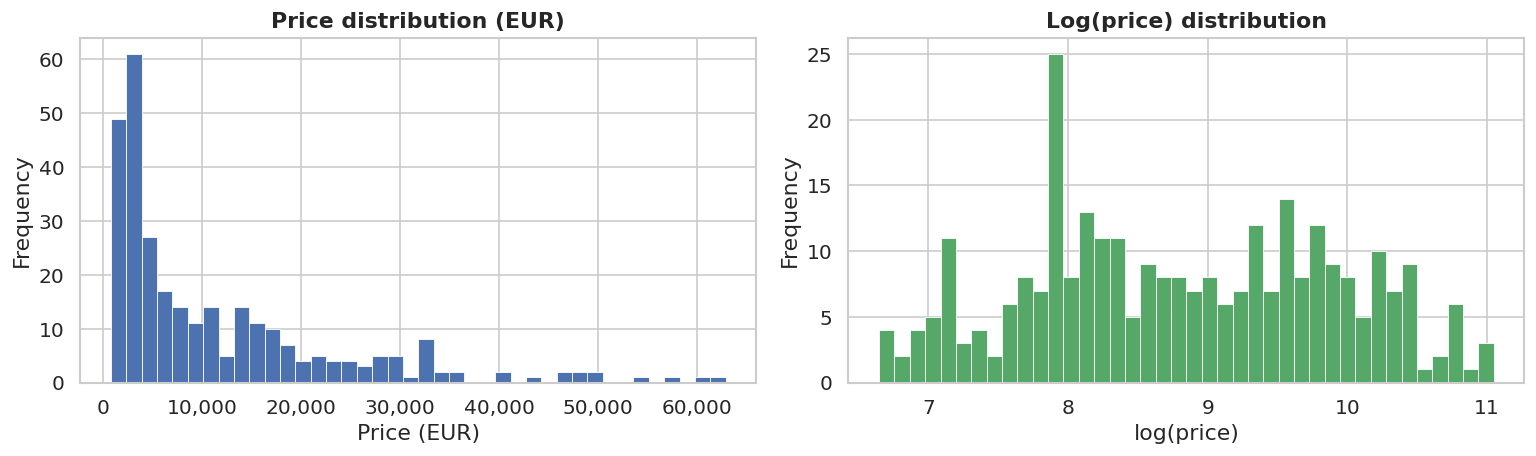

Skewness original price: 1.74
Skewness log-price:      0.03
6381.0
11525.550675675675
770
62892


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Original price
axes[0].hist(df_clean['price_current'], bins=40,
             color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].set_title('Price distribution (EUR)', fontweight='bold')
axes[0].set_xlabel('Price (EUR)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Log-price
axes[1].hist(df_clean['log_price'], bins=40,
             color='#55A868', edgecolor='white', linewidth=0.5)
axes[1].set_title('Log(price) distribution', fontweight='bold')
axes[1].set_xlabel('log(price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('fig_price_distribution.png', bbox_inches='tight')
plt.show()

print(f'Skewness original price: {df_clean["price_current"].skew():.2f}')
print(f'Skewness log-price:      {df_clean["log_price"].skew():.2f}')
print(df_clean['price_current'].median())
print(df_clean['price_current'].mean())
print(df_clean['price_current'].min())
print(df_clean['price_current'].max())

### 3.2 Price by Brand

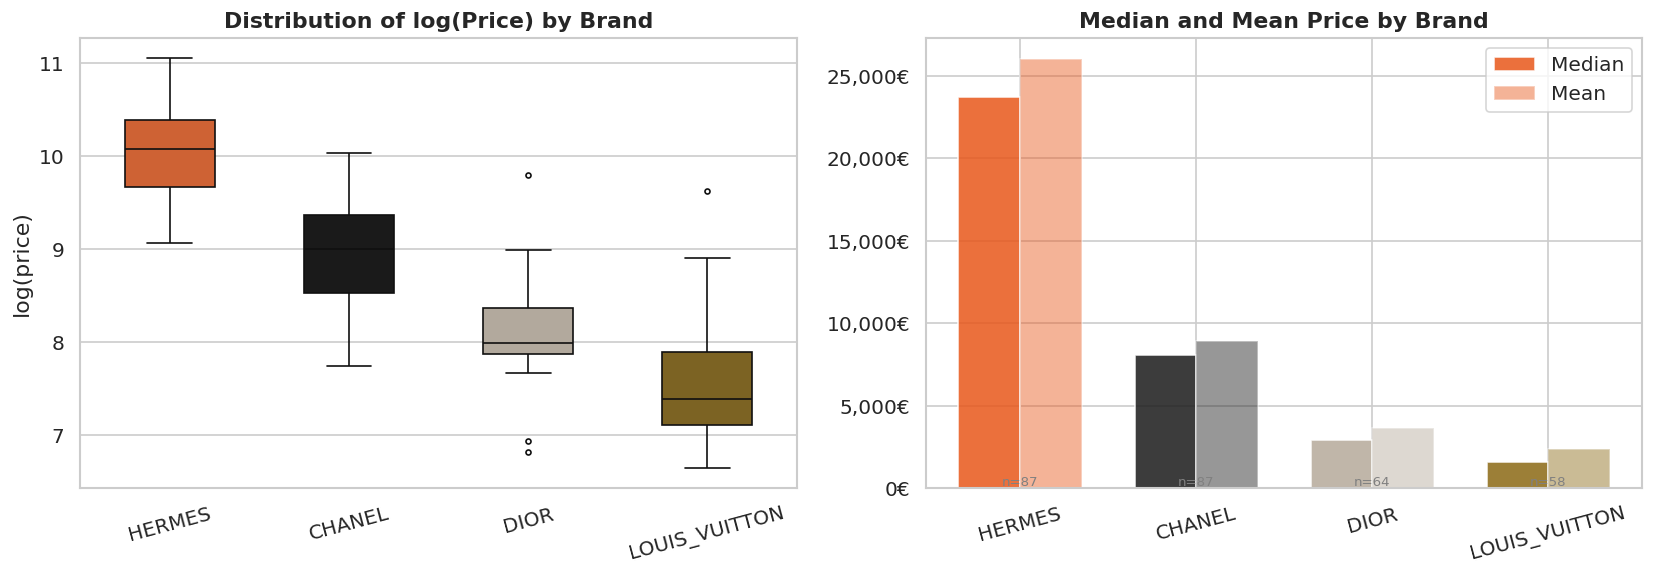

                median     mean  count
brand                                 
HERMES         23693.0  26009.0     87
CHANEL          8094.0   8954.0     87
DIOR            2945.0   3642.0     64
LOUIS_VUITTON   1621.0   2358.0     58


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Log-price boxplot by brand
brand_order = (df_clean.groupby('brand')['price_current']
               .median().sort_values(ascending=False).index.tolist())

sns.boxplot(
    data=df_clean, x='brand', y='log_price',
    order=brand_order,
    palette=BRAND_COLORS,
    width=0.5, fliersize=3, ax=axes[0]
)
axes[0].set_title('Distribution of log(Price) by Brand', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('log(price)')
axes[0].set_xticklabels(brand_order, rotation=15)

#Median and mean price by brand
stats_brand = (df_clean.groupby('brand')['price_current']
               .agg(['median', 'mean', 'count'])
               .loc[brand_order])


x = np.arange(len(brand_order))
w = 0.35
bars1 = axes[1].bar(x - w/2, stats_brand['median'], w,
                    label='Median', color=[BRAND_COLORS[b] for b in brand_order], alpha=0.85)
bars2 = axes[1].bar(x + w/2, stats_brand['mean'], w,
                    label='Mean', color=[BRAND_COLORS[b] for b in brand_order], alpha=0.45)

axes[1].set_xticks(x)
axes[1].set_xticklabels(brand_order, rotation=15)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
axes[1].set_title('Median and Mean Price by Brand', fontweight='bold')
axes[1].legend()

# N labels
for i, brand in enumerate(brand_order):
    n = stats_brand.loc[brand, 'count']
    axes[1].annotate(f'n={n}', xy=(i, 200), ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('fig_price_by_brand.png', bbox_inches='tight')
plt.show()

print(stats_brand.round(0))

### 3.3 Price by Model

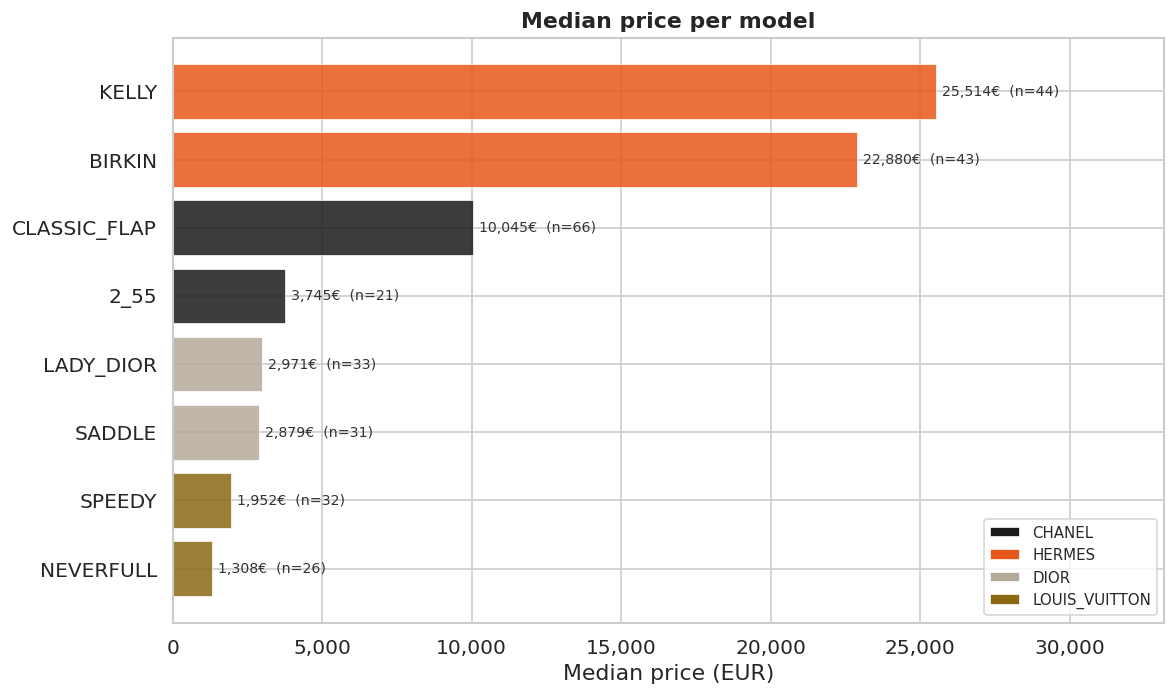

In [56]:
# Median price by model
model_stats = (
    df_clean.groupby(['brand', 'model_family'])['price_current']
    .agg(['median', 'count'])
    .reset_index()
    .rename(columns={'median': 'Mediana', 'count': 'N'})
    .sort_values('Mediana', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

colors_bar = [BRAND_COLORS[b] for b in model_stats['brand']]
bars = ax.barh(model_stats['model_family'], model_stats['Mediana'],
               color=colors_bar, edgecolor='white', linewidth=0.5, alpha=0.85)

# Labels with median and n
for bar, (_, row) in zip(bars, model_stats.iterrows()):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{row["Mediana"]:,.0f}€  (n={row["N"]})',
            va='center', fontsize=8.5, color='#333333')

# Brand legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=b) for b, c in BRAND_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Median price (EUR)')
ax.set_title('Median price per model', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, model_stats['Mediana'].max() * 1.3)

plt.tight_layout()
plt.savefig('fig_price_by_model.png', bbox_inches='tight')
plt.show()

### 3.4 Effect of Condition on Price

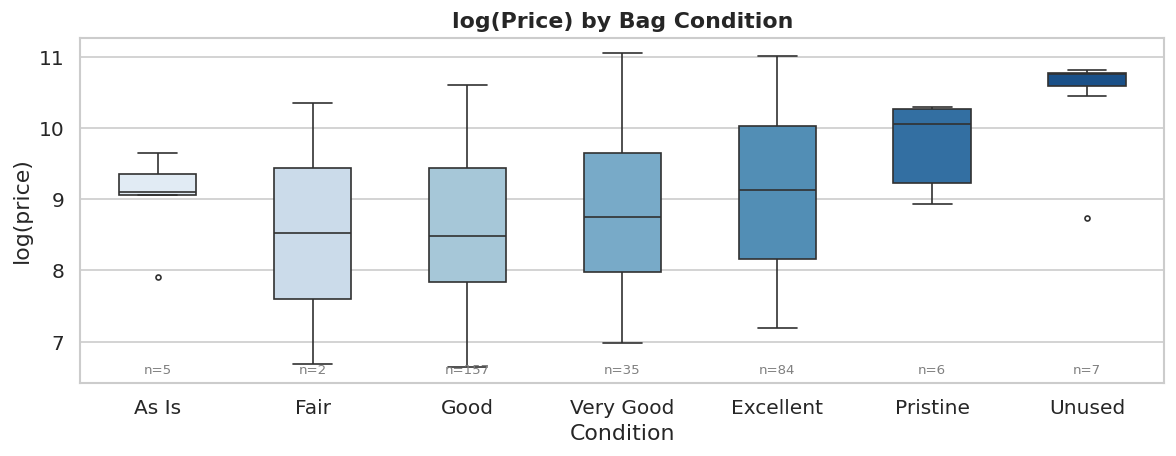

Spearman correlation (condition_score vs log_price): ρ = 0.290, p = 0.0000


In [57]:
condition_order = ['As Is', 'Fair', 'Good', 'Very Good', 'Excellent', 'Pristine', 'Unused']
df_cond = df_clean[df_clean['condition_raw'].isin(condition_order)]

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=df_cond, x='condition_raw', y='log_price',
    order=condition_order,
    palette='Blues', width=0.5, fliersize=3, ax=ax
)
ax.set_title('log(Price) by Bag Condition', fontweight='bold')
ax.set_xlabel('Condition')
ax.set_ylabel('log(price)')

# N per category
counts = df_cond['condition_raw'].value_counts()
for i, cond in enumerate(condition_order):
    n = counts.get(cond, 0)
    ax.text(i, df_cond['log_price'].min() - 0.1, f'n={n}',
            ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('fig_price_by_condition.png', bbox_inches='tight')
plt.show()

# Spearman correlation
df_corr = df_clean.dropna(subset=['condition_score', 'log_price'])
rho, p = stats.spearmanr(df_corr['condition_score'], df_corr['log_price'])
print(f'Spearman correlation (condition_score vs log_price): ρ = {rho:.3f}, p = {p:.4f}')

### 3.5 Relationship Between Age and Price

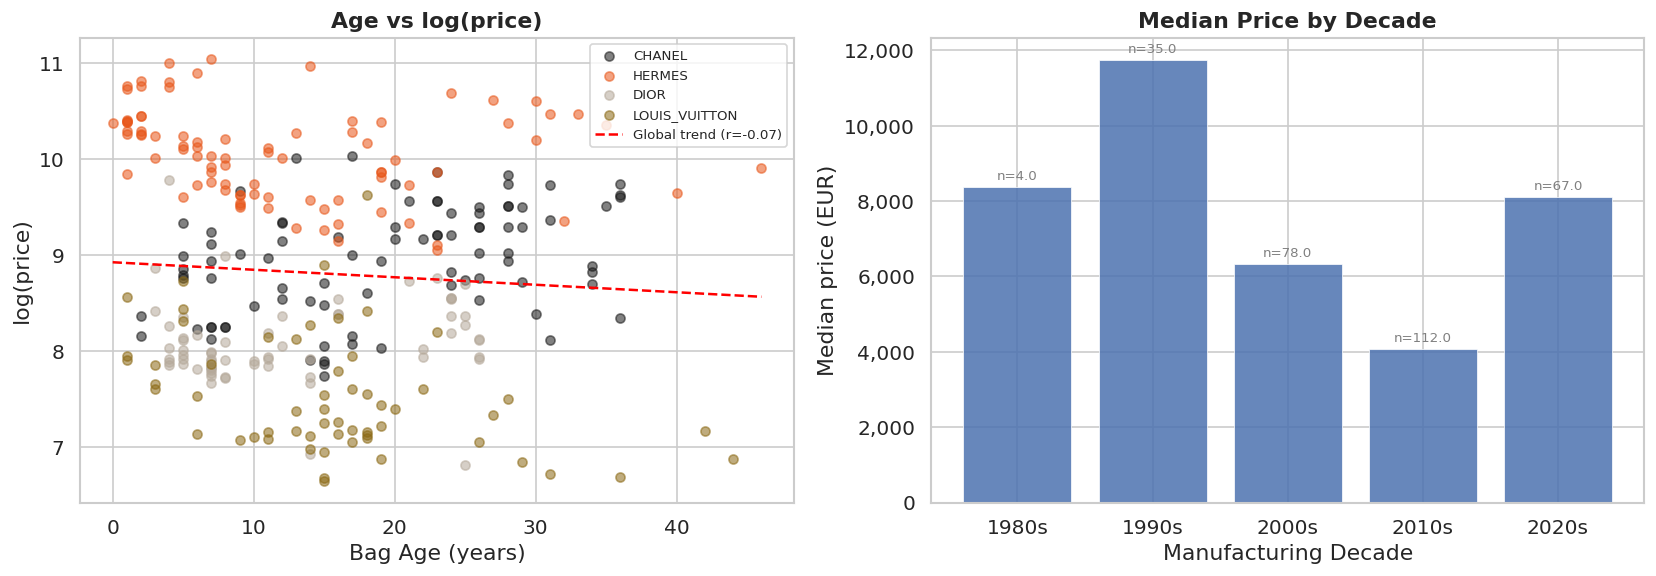

In [58]:
df_age = df_clean.dropna(subset=['age'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter age vs log_price coloured by brand
for brand, color in BRAND_COLORS.items():
    mask = df_age['brand'] == brand
    axes[0].scatter(df_age.loc[mask, 'age'], df_age.loc[mask, 'log_price'],
                    color=color, alpha=0.55, s=30, label=brand)

# Global trend line
slope, intercept, r, p, _ = stats.linregress(df_age['age'], df_age['log_price'])
x_line = np.linspace(df_age['age'].min(), df_age['age'].max(), 100)
axes[0].plot(x_line, intercept + slope * x_line,
             color='red', linestyle='--', linewidth=1.5, label=f'Global trend (r={r:.2f})')
axes[0].set_xlabel('Bag Age (years)')
axes[0].set_ylabel('log(price)')
axes[0].set_title('Age vs log(price)', fontweight='bold')
axes[0].legend(fontsize=8)

# Median price by manufacturing decade
df_age = df_age.copy()
df_age['decade'] = (pd.to_numeric(df_age['year_clean'], errors='coerce') // 10 * 10).astype(int).astype(str) + 's'
decade_stats = (df_age.groupby('decade')['price_current']
                .agg(['median', 'count'])
                .sort_index())

axes[1].bar(decade_stats.index, decade_stats['median'],
            color='#4C72B0', edgecolor='white', linewidth=0.5, alpha=0.85)
for i, (dec, row) in enumerate(decade_stats.iterrows()):
    axes[1].text(i, row['median'] + 200, f'n={row["count"]}',
                 ha='center', fontsize=8, color='gray')
axes[1].set_xlabel('Manufacturing Decade')
axes[1].set_ylabel('Median price (EUR)')
axes[1].set_title('Median Price by Decade', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('fig_age_price.png', bbox_inches='tight')
plt.show()

### 3.6 Price by Material

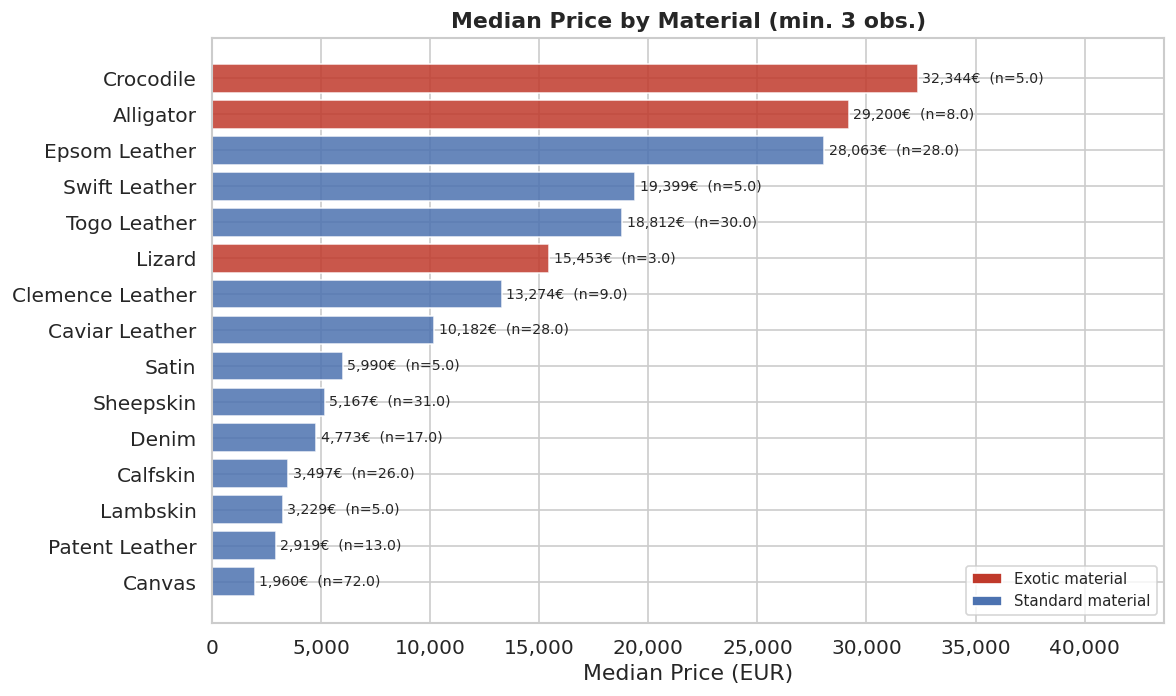

In [59]:
mat_stats = (
    df_clean.groupby('material_raw')['price_current']
    .agg(['median', 'count'])
    .query('count >= 3')
    .sort_values('median', ascending=True)
)

# Highlight exotic materials
exotic_mats = ['Alligator', 'Crocodile', 'Lizard']
colors_mat = ['#C0392B' if m in exotic_mats else '#4C72B0'
              for m in mat_stats.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(mat_stats.index, mat_stats['median'],
               color=colors_mat, edgecolor='white', alpha=0.85)

for bar, (mat, row) in zip(bars, mat_stats.iterrows()):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{row["median"]:,.0f}€  (n={row["count"]})',
            va='center', fontsize=8.5)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#C0392B', label='Exotic material'),
    Patch(facecolor='#4C72B0', label='Standard material')
], fontsize=9)

ax.set_xlabel('Median Price (EUR)')
ax.set_title('Median Price by Material (min. 3 obs.)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, mat_stats['median'].max() * 1.35)

plt.tight_layout()
plt.savefig('fig_price_by_material.png', bbox_inches='tight')
plt.show()

### 3.7 Effect of Accessories on Price

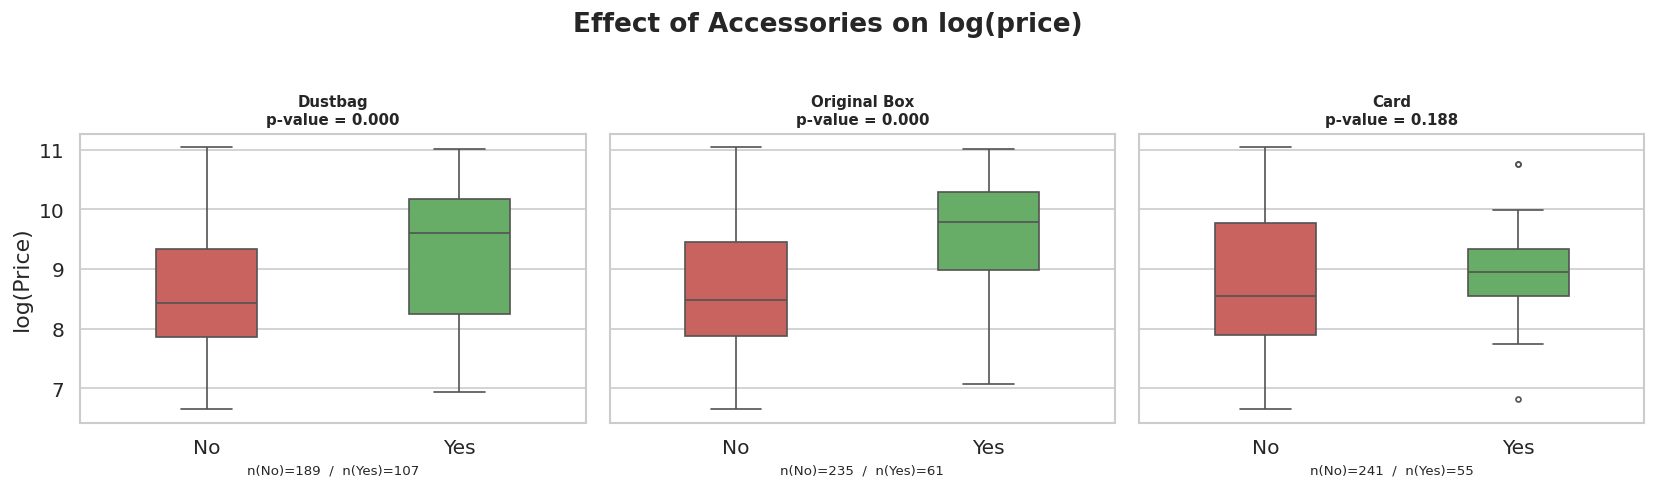

In [60]:
# Compare price of bags with and without dustbag / box / card
acc_cols = {
    'includes_dustbag':              'Dustbag',
    'includes_box':          'Original Box',
    'includes_card_of_certificate':  'Card'
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (col, label) in zip(axes, acc_cols.items()):
    df_acc = df_clean.dropna(subset=[col])
    df_acc = df_acc[df_acc[col].isin([0, 1])].copy()
    df_acc['has'] = df_acc[col].map({1: 'Yes', 0: 'No'})

    sns.boxplot(data=df_acc, x='has', y='log_price',
                order=['No', 'Yes'], palette=['#d9534f', '#5cb85c'],
                width=0.4, fliersize=3, ax=ax)

    # Mann-Whitney U test (non-parametric)
    group_yes  = df_acc[df_acc['has'] == 'Yes']['log_price'].dropna()
    group_no  = df_acc[df_acc['has'] == 'No']['log_price'].dropna()
    if len(group_yes) > 0 and len(group_no) > 0:
        _, p_val = stats.mannwhitneyu(group_yes, group_no, alternative='greater')
        ax.set_title(f'{label}\np-value = {p_val:.3f}', fontweight='bold', fontsize=9)
    else:
        ax.set_title(label, fontweight='bold', fontsize=9)

    n_yes = (df_acc['has'] == 'Yes').sum()
    n_no = (df_acc['has'] == 'No').sum()
    ax.set_xlabel(f'n(No)={n_no}  /  n(Yes)={n_yes}', fontsize=8)
    ax.set_ylabel('log(Price)' if ax == axes[0] else '')

plt.suptitle('Effect of Accessories on log(price)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_accessories.png', bbox_inches='tight')
plt.show()

### 3.8 Platform Differences

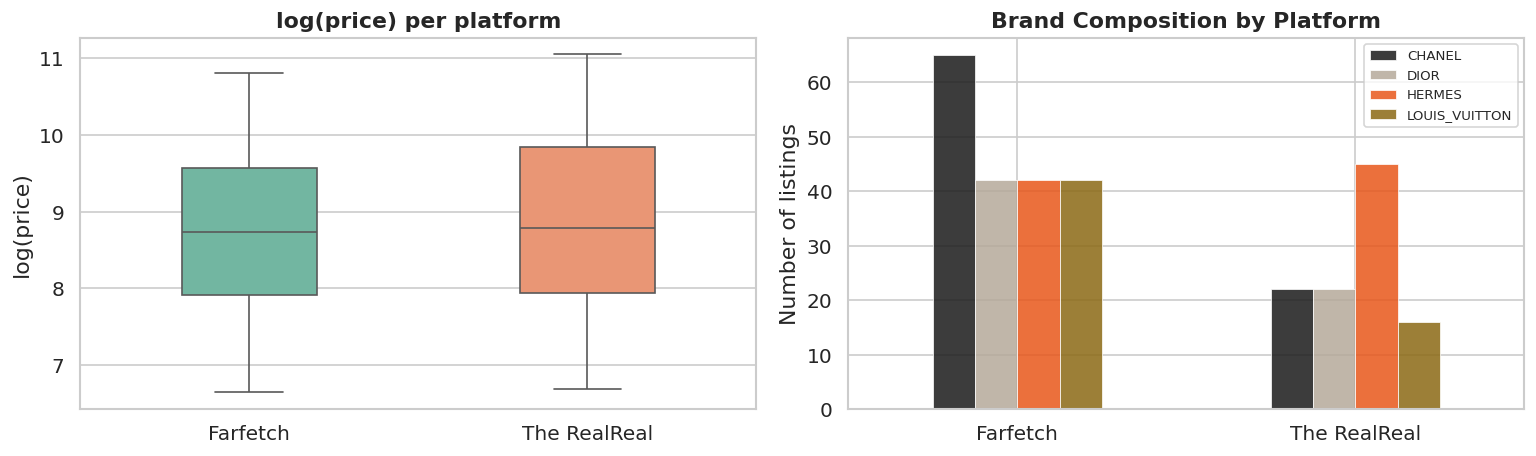

Mann-Whitney Farfetch vs The RealReal: p = 0.2985
Median Farfetch:       6,196€
Median The RealReal:   6,589€


In [61]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution by platform
sns.boxplot(data=df_clean, x='platform', y='log_price',
            palette='Set2', width=0.4, fliersize=3, ax=axes[0])
axes[0].set_title('log(price) per platform', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('log(price)')

# Brand composition by platform
brand_platform = (df_clean.groupby(['platform', 'brand'])
                  .size().unstack(fill_value=0))
brand_platform.plot(kind='bar', ax=axes[1],
                    color=[BRAND_COLORS[b] for b in brand_platform.columns],
                    edgecolor='white', linewidth=0.5, alpha=0.85)
axes[1].set_title('Brand Composition by Platform', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of listings')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fig_platform.png', bbox_inches='tight')
plt.show()

# Mann-Whitney U test between platforms
ff   = df_clean[df_clean['platform'] == 'Farfetch']['log_price'].dropna()
rr   = df_clean[df_clean['platform'] == 'The RealReal']['log_price'].dropna()
_, p = stats.mannwhitneyu(ff, rr, alternative='two-sided')
print(f'Mann-Whitney Farfetch vs The RealReal: p = {p:.4f}')
print(f'Median Farfetch:       {ff.apply(np.exp).median():,.0f}€')
print(f'Median The RealReal:   {rr.apply(np.exp).median():,.0f}€')

### 3.9 Correlation Matrix of Numeric Variables

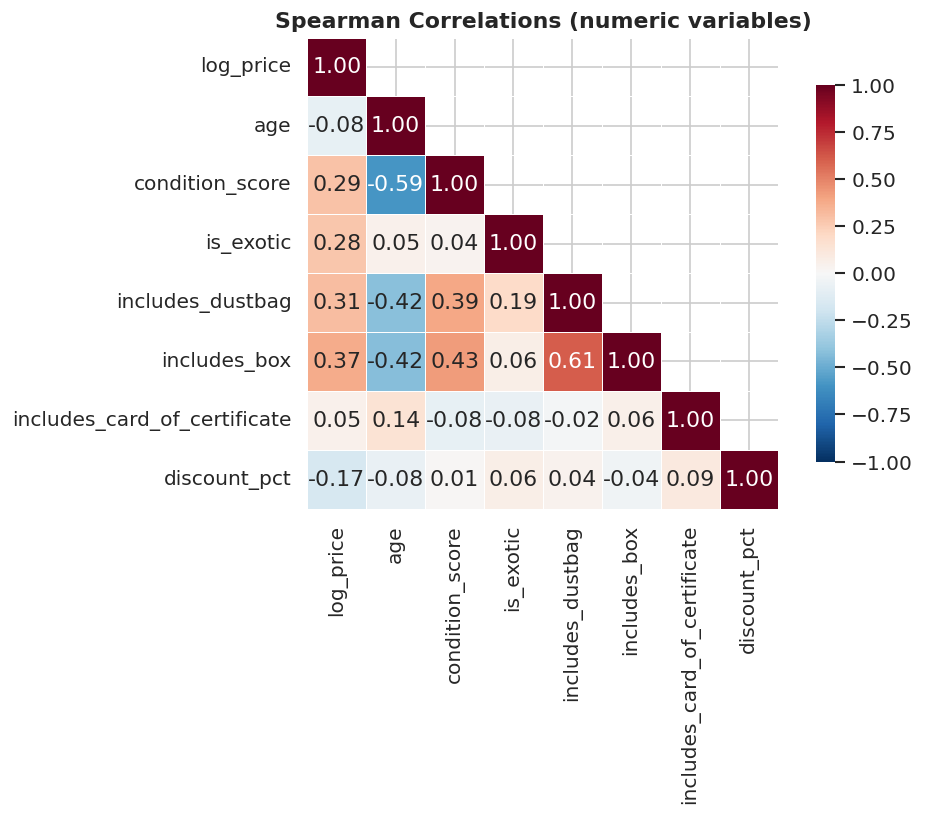

In [62]:
NUM_COLS = [
    'log_price', 'age', 'condition_score',
    'is_exotic', 'includes_dustbag',
    'includes_box', 'includes_card_of_certificate', 'discount_pct'
]

corr_matrix = df_clean[NUM_COLS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Spearman Correlations (numeric variables)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', bbox_inches='tight')
plt.show()

### 3.10 Descriptive Statistics by Brand and Model

In [63]:
summary = (
    df_clean.groupby(['brand', 'model_family'])['price_current']
    .agg(
        N='count',
        Min='min',
        Q1=lambda x: x.quantile(0.25),
        Median='median',
        Q3=lambda x: x.quantile(0.75),
        Max='max',
        CV=lambda x: (x.std() / x.mean() * 100)
    )
    .round(0)
)
summary['CV'] = summary['CV'].round(1).astype(str) + '%'
print('Price (EUR) summary by brand and model:')
summary

Price (EUR) summary by brand and model:


N   Min       Q1   Median       Q3    Max     CV
brand         model_family                                                   
CHANEL        2_55          21  2312   3141.0   3745.0   4306.0   9800  49.0%
              CLASSIC_FLAP  66  3369   6640.0  10045.0  13488.0  22707  43.0%
DIOR          LADY_DIOR     33  1028   2710.0   2971.0   3902.0  17846  75.0%
              SADDLE        31   912   2505.0   2879.0   4306.0   7108  42.0%
HERMES        BIRKIN        43  8602  16440.0  22880.0  31058.0  60231  50.0%
              KELLY         44  9397  15419.0  25514.0  32490.0  62892  47.0%
LOUIS_VUITTON NEVERFULL     26  1076   1240.0   1308.0   1904.0   7310  73.0%
              SPEEDY        32   770   1129.0   1952.0   3419.0  15152  98.0%

# **PART 2: Feature Engineering and Hedonic Baseline Model**

## 0. Libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

BRAND_COLORS = {
    'CHANEL':        '#1a1a1a',
    'HERMES':        '#E8571A',
    'DIOR':          '#B5A99A',
    'LOUIS_VUITTON': '#8B6914'
}

RANDOM_STATE = 42


## 1. Load and verify the clean dataset

In [65]:

FILE_PATH = 'resale_listings_clean.csv'

df = pd.read_csv(FILE_PATH)
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')

df.head(3)

Dataset loaded: 296 rows x 29 columns


,row_id,platform,brand,model_family,model_variant,size_raw,material_raw,material_group,is_exotic,color_raw,...,includes_box,includes_card_of_certificate,discount_flag,discount_pct,price_current,log_price,product_key_core,product_key_extended,title_raw,description_raw
0,R_000001,Farfetch,CHANEL,CLASSIC_FLAP,NaN,Mini Square,Satin,Satin,0,Black,...,0,1,0,0.0,6419,8.767018,CHANEL_CLASSIC_FLAP_MINI_SQUARE_SATIN,CHANEL_CLASSIC_FLAP_MINI_SQUARE_SATIN_BLACK_GOLD,Chanel Pre-Owned 2000 mini square Classic Flap...,"circa 2000, black, satin weave, diamond quilti..."
1,R_000002,Farfetch,CHANEL,CLASSIC_FLAP,NaN,Jumbo,Caviar Leather,Caviar Leather,0,Beige,...,1,1,0,0.0,7645,8.941807,CHANEL_CLASSIC_FLAP_JUMBO_CAVIAR,CHANEL_CLASSIC_FLAP_JUMBO_CAVIAR_BEIGE_GOLD,Chanel Pre-Owned 1998 Classic Flap shoulder bag,"circa 1998, beige, caviar leather, diamond qui..."
2,R_000003,Farfetch,CHANEL,CLASSIC_FLAP,NaN,Jumbo,Caviar Leather,Caviar Leather,0,Black,...,0,1,0,0.0,8343,9.029178,CHANEL_CLASSIC_FLAP_JUMBO_CAVIAR,CHANEL_CLASSIC_FLAP_JUMBO_CAVIAR_BLACK_GOLD,Chanel Pre-Owned 1998 Classic Flap shoulder bag,"circa 1998, black, caviar leather, grained tex..."


## 2. Feature Engineering

### 2.7 Age and Age_sq

In [66]:
# age_sq added to capture potential non-linearity in the vintage effect
df['age_sq'] = df['age'] ** 2

# Verify there are no NaN in age
print(f'NaN en age: {df["age"].isna().sum()}')
print(f'Rango age: {df["age"].min():.0f} — {df["age"].max():.0f} años')

NaN en age: 0
Rango age: 0 — 46 años


### 2.8 Feature Matrix Construction (Dummies)

In [67]:
print(df.columns.tolist())

['row_id', 'platform', 'brand', 'model_family', 'model_variant', 'size_raw', 'material_raw', 'material_group', 'is_exotic', 'color_raw', 'color_clean', 'hardware_raw', 'year_raw', 'year_clean', 'age', 'made_in_country', 'condition_raw', 'condition_score', 'includes_dustbag', 'includes_box', 'includes_card_of_certificate', 'discount_flag', 'discount_pct', 'price_current', 'log_price', 'product_key_core', 'product_key_extended', 'title_raw', 'description_raw', 'age_sq']


In [68]:
# Categorical variables into dummies

# Calfskin as reference for material_group
df['material_group'] = pd.Categorical(
    df['material_group'],
    categories=['Calfskin'] + [x for x in sorted(df['material_group'].unique()) if x != 'Calfskin']
)

# CLASSIC_FLAP as reference for model_family
df['model_family'] = pd.Categorical(
    df['model_family'],
    categories=['CLASSIC_FLAP'] + [x for x in sorted(df['model_family'].unique()) if x != 'CLASSIC_FLAP']
)

# Black as reference for color_clean
df['color_clean'] = pd.Categorical(
    df['color_clean'],
    categories=['Black'] + [x for x in sorted(df['color_clean'].unique()) if x != 'Black']
)

CATEGORICAL_VARS = [
    'brand', 'model_family', 'material_group',
    'color_clean', 'hardware_raw', 'platform', 'model_variant'
]

NUMERIC_VARS = [
    'age', 'age_sq', 'condition_score',
    'is_exotic', 'includes_box',
    'includes_dustbag', 'discount_pct', "includes_card_of_certificate"
]

# Create dummies
df_dummies = pd.get_dummies(
    df[CATEGORICAL_VARS + NUMERIC_VARS + ['log_price']],
    columns=CATEGORICAL_VARS,
    drop_first=True,
    dtype=int
)

print(f'Feature matrix dimensions: {df_dummies.shape}')
print(f'Total features (excluding target): {df_dummies.shape[1] - 1}')
print(f'\nFirst Columns:')
print(df_dummies.columns.tolist()[:20])

Feature matrix dimensions: (296, 53)
Total features (excluding target): 52

First Columns:
['age', 'age_sq', 'condition_score', 'is_exotic', 'includes_box', 'includes_dustbag', 'discount_pct', 'includes_card_of_certificate', 'log_price', 'brand_DIOR', 'brand_HERMES', 'brand_LOUIS_VUITTON', 'model_family_2_55', 'model_family_BIRKIN', 'model_family_KELLY', 'model_family_LADY_DIOR', 'model_family_NEVERFULL', 'model_family_SADDLE', 'model_family_SPEEDY', 'material_group_Alligator']


## 3. Train / Test Split

In [69]:
# Separate features and target
X = df_dummies.drop(columns=['log_price'])
y = df_dummies['log_price']

# Stratify by brand to preserve distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df['brand']
)

print(f'Train: {len(X_train)} records ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test:  {len(X_test)} records ({len(X_test)/len(X)*100:.1f}%)')
print()

# Verify brand distribution
train_brands = df.loc[X_train.index, 'brand'].value_counts(normalize=True).round(3)
test_brands  = df.loc[X_test.index,  'brand'].value_counts(normalize=True).round(3)
print('Brand distribution: Train vs Test:')
print(pd.DataFrame({'Train': train_brands, 'Test': test_brands}))

Train: 236 records (79.7%)
Test:  60 records (20.3%)

Brand distribution: Train vs Test:
               Train   Test
brand                      
CHANEL         0.292  0.300
DIOR           0.216  0.217
HERMES         0.297  0.283
LOUIS_VUITTON  0.195  0.200


## 4. Hedonic Baseline Model (OLS)

In [70]:
# Add constant (intercept)
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# Estimate OLS with HC3 robust standard errors
model_ols = sm.OLS(y_train, X_train_sm).fit(cov_type='HC3')

print(f'R2 (train): {model_ols.rsquared:.4f}')
print(f'Adjusted R2 (train): {model_ols.rsquared_adj:.4f}')
print(f'Train observations: {int(model_ols.nobs)}')
print(f'Variables: {len(model_ols.params)}')

R2 (train): 0.9163
Adjusted R2 (train): 0.8949
Train observations: 236
Variables: 53


In [71]:
# Full model summary
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     72.07
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           9.29e-98
Time:                        20:11:13   Log-Likelihood:                -60.735
No. Observations:                 236   AIC:                             219.5
Df Residuals:                     187   BIC:                             389.2
Df Model:                          48                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

## 5. Model Evaluation

In [72]:
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

# Predictions on train and test sets
y_pred_train = model_ols.predict(X_train_sm)
y_pred_test  = model_ols.predict(X_test_sm)

# Metrics in log scale
rmse_train_log = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test_log  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
r2_test        = r2_score(y_test, y_pred_test)

# Convert RMSE to EUR for interpretability (approximate average error in euros)

rmse_train_eur = np.exp(y_train.mean()) * (np.exp(rmse_train_log) - 1)
rmse_test_eur  = np.exp(y_test.mean())  * (np.exp(rmse_test_log)  - 1)
mae_ols = mean_absolute_error(y_test, y_pred_test)
corr_ols, _ = pearsonr(y_test, y_pred_test)


print('OLS HEDONIC BASELINE MODEL METRICS')
print(f'R2 train:        {model_ols.rsquared:.4f}')
print(f'R2 test:         {r2_test:.4f}')
print(f'RMSE train (log): {rmse_train_log:.4f}')
print(f'RMSE test  (log): {rmse_test_log:.4f}')
print(f'RMSE train (€):   {rmse_train_eur:,.0f}€')
print(f'RMSE test  (€):   {rmse_test_eur:,.0f}€')
print(f"MAE (log):        {mae_ols:.4f}")
print(f"Pearson r:        {corr_ols:.4f}")
print()


OLS HEDONIC BASELINE MODEL METRICS
R2 train:        0.9163
R2 test:         0.7704
RMSE train (log): 0.3130
RMSE test  (log): 0.5123
RMSE train (€):   2,502€
RMSE test  (€):   4,248€
MAE (log):        0.3968
Pearson r:        0.8783



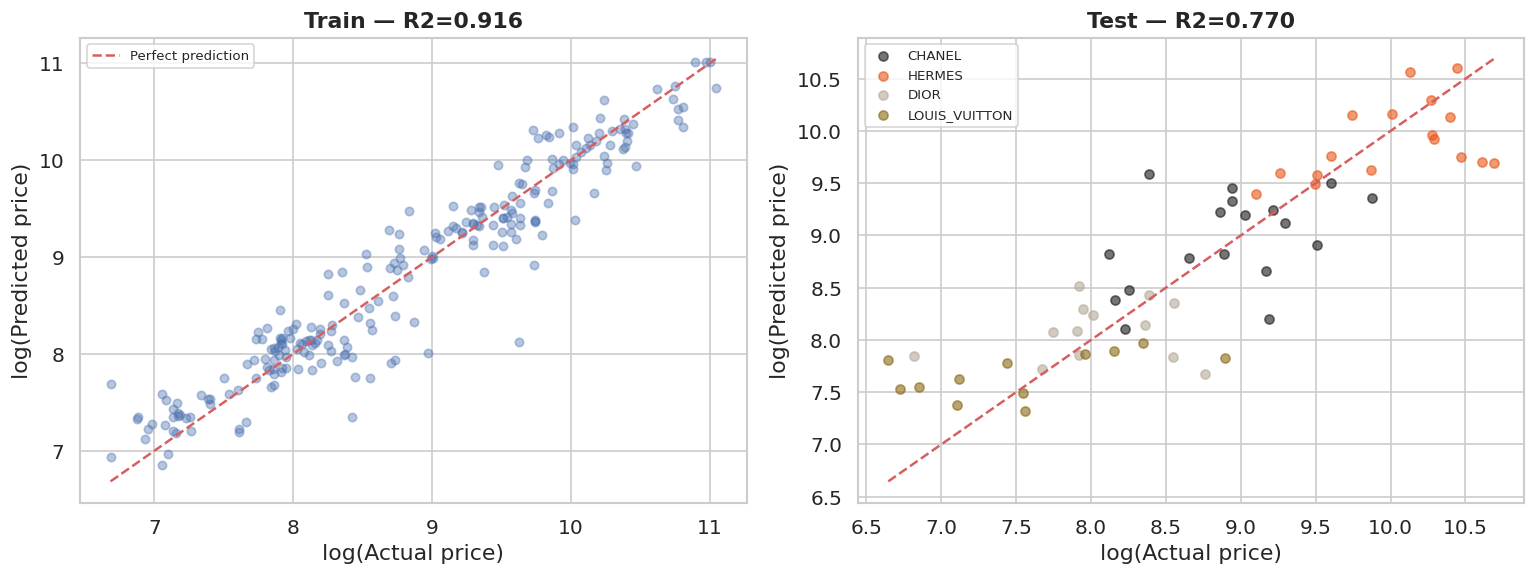

In [73]:
# Actual vs predicted values
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Train
axes[0].scatter(y_train, y_pred_train, alpha=0.4, s=25, color='#4C72B0')
lims = [min(y_train.min(), y_pred_train.min()), max(y_train.max(), y_pred_train.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('log(Actual price)')
axes[0].set_ylabel('log(Predicted price)')
axes[0].set_title(f'Train — R2={model_ols.rsquared:.3f}', fontweight='bold')
axes[0].legend(fontsize=8)

# Test
# Colour by brand
test_brands_list = df.loc[X_test.index, 'brand'].values
for brand, color in BRAND_COLORS.items():
    mask = test_brands_list == brand
    axes[1].scatter(y_test[mask], y_pred_test[mask],
                    alpha=0.6, s=30, color=color, label=brand)
lims2 = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[1].plot(lims2, lims2, 'r--', linewidth=1.5)
axes[1].set_xlabel('log(Actual price)')
axes[1].set_ylabel('log(Predicted price)')
axes[1].set_title(f'Test — R2={r2_test:.3f}', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_ols_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

## 6. Coefficient Interpretation

In [74]:
# Table of significant coefficients
coef_df = pd.DataFrame({
    'Coefficient': model_ols.params,
    'Std Error':   model_ols.HC3_se,
    'p-value':     model_ols.pvalues,
    'IC 2.5%':     model_ols.conf_int()[0],
    'IC 97.5%':    model_ols.conf_int()[1]
})

# Percentage effect on price
coef_df['Effect_%'] = (np.exp(coef_df['Coefficient']) - 1) * 100

# Effect in EUR (on median price)
precio_mediano = df['price_current'].median()
coef_df['Effect_EUR'] = coef_df['Effect_%'] / 100 * precio_mediano

# Filter significant coefficients (p < 0.05) and sort by effect
coef_sig = (coef_df[coef_df['p-value'] < 0.05]
            .drop('const', errors='ignore')
            .sort_values('Effect_%', ascending=False))

print(f'Significant coefficients (p<0.05): {len(coef_sig)}')
print()
print(coef_sig[['Coefficient','p-value','Effect_%','Effect_EUR']].round(3).to_string())

Significant coefficients (p<0.05): 19

                          Coefficient  p-value  Effect_%  Effect_EUR
material_group_Crocodile        1.176    0.007   224.080   14298.531
material_group_Alligator        0.934    0.009   154.343    9848.614
material_group_Denim            0.488    0.006    62.926    4015.309
brand_HERMES                    0.464    0.011    59.092    3770.679
model_family_BIRKIN             0.385    0.000    47.013    2999.904
material_group_Lambskin         0.309    0.028    36.262    2313.884
includes_box                    0.190    0.025    20.970    1338.089
condition_score                 0.087    0.011     9.091     580.085
color_clean_Red                -0.210    0.030   -18.946   -1208.955
model_family_LADY_DIOR         -0.304    0.000   -26.189   -1671.097
platform_The RealReal          -0.308    0.000   -26.476   -1689.460
color_clean_Orange             -0.417    0.001   -34.127   -2177.645
model_family_SADDLE            -0.471    0.000   -37.577   -2397

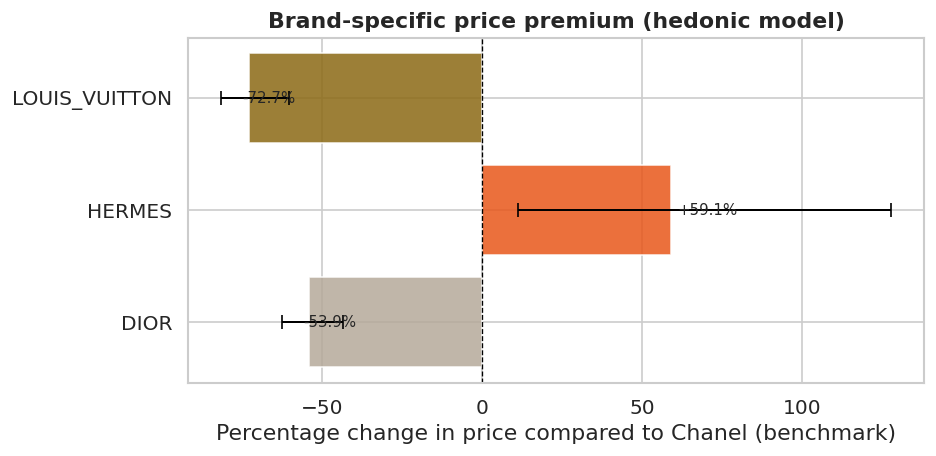

In [75]:
# Chart 1: Brand premium (reference: CHANEL)
brand_coefs = coef_df[coef_df.index.str.startswith('brand_')].copy()
brand_coefs.index = brand_coefs.index.str.replace('brand_', '')
brand_coefs['color'] = brand_coefs.index.map(
    lambda x: BRAND_COLORS.get(x, '#888888')
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(brand_coefs.index, brand_coefs['Effect_%'],
               color=brand_coefs['color'], alpha=0.85, edgecolor='white')

# Confidence interval
ic_low  = (np.exp(brand_coefs['IC 2.5%'])  - 1) * 100
ic_high = (np.exp(brand_coefs['IC 97.5%']) - 1) * 100
ax.errorbar(brand_coefs['Effect_%'], brand_coefs.index,
            xerr=[brand_coefs['Effect_%'] - ic_low,
                  ic_high - brand_coefs['Effect_%']],
            fmt='none', color='black', capsize=4, linewidth=1.2)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Percentage change in price compared to Chanel (benchmark)')
ax.set_title('Brand-specific price premium (hedonic model)', fontweight='bold')

# Labels
for bar, pct in zip(bars, brand_coefs['Effect_%']):
    sign = '+' if pct >= 0 else ''
    ax.text(pct + (2 if pct >= 0 else -2), bar.get_y() + bar.get_height()/2,
            f'{sign}{pct:.1f}%', va='center', fontsize=9)


plt.tight_layout()
plt.savefig('fig_brand_premium.png', bbox_inches='tight')
plt.show()


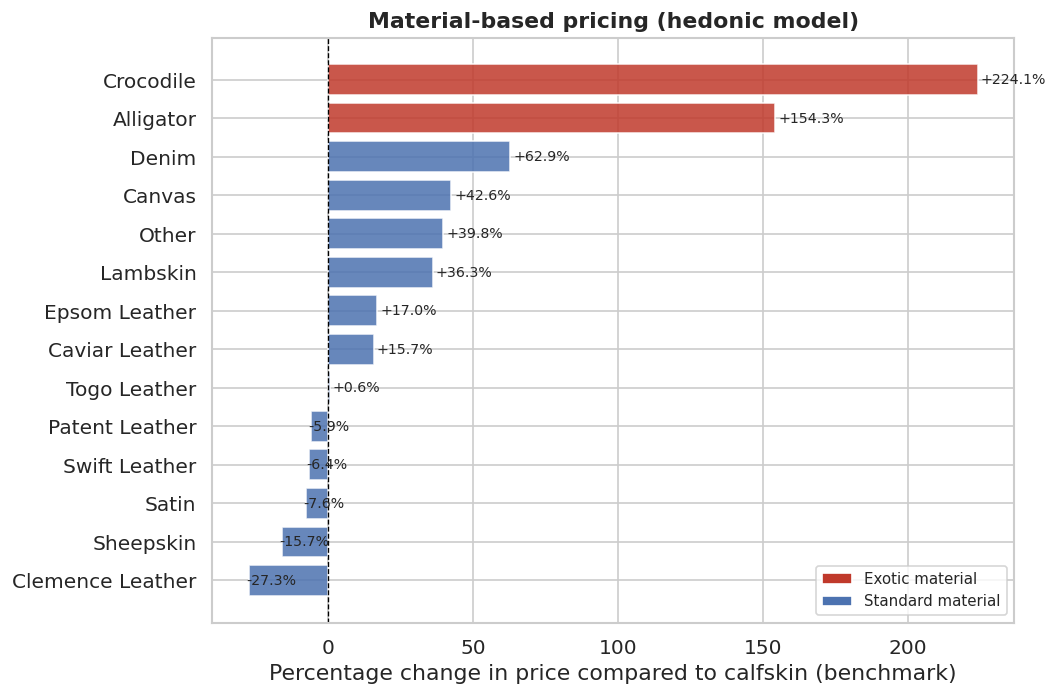

In [76]:
# Chart 2: Material premium (reference: Calfskin)
mat_coefs = coef_df[coef_df.index.str.startswith('material_group_')].copy()
mat_coefs.index = mat_coefs.index.str.replace('material_group_', '')
mat_coefs = mat_coefs.sort_values('Effect_%', ascending=True)

colors_mat = ['#C0392B' if 'Alligator' in i or 'Crocodile' in i or 'Lizard' in i
              else '#4C72B0' for i in mat_coefs.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(mat_coefs.index, mat_coefs['Effect_%'],
               color=colors_mat, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Percentage change in price compared to calfskin (benchmark)')
ax.set_title('Material-based pricing (hedonic model)', fontweight='bold')

for bar, pct in zip(bars, mat_coefs['Effect_%']):
    sign = '+' if pct >= 0 else ''
    ax.text(pct + (1 if pct >= 0 else -1), bar.get_y() + bar.get_height()/2,
            f'{sign}{pct:.1f}%', va='center', fontsize=8.5)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#C0392B', label='Exotic material'),
    Patch(facecolor='#4C72B0', label='Standard material')
], fontsize=9)

plt.tight_layout()
plt.savefig('fig_material_premium.png', bbox_inches='tight')
plt.show()

In [77]:
# Summary table: key continuous and binary variables
KEY_VARS = ['age', 'age_sq', 'condition_score',
            'is_exotic', 'includes_box', 'discount_pct', "includes_dustbag", "includes_card_of_certificate"]

key_coefs = coef_df.loc[
    [v for v in KEY_VARS if v in coef_df.index]
][['Coefficient', 'p-value', 'Effect_%', 'Effect_EUR']].round(3)

print('KEY CONTINUOUS AND BINARY VARIABLES')
print(key_coefs.to_string())
print()


KEY CONTINUOUS AND BINARY VARIABLES
                              Coefficient  p-value  Effect_%  Effect_EUR
age                                -0.003    0.821    -0.289     -18.412
age_sq                             -0.000    0.629    -0.016      -1.052
condition_score                     0.087    0.011     9.091     580.085
is_exotic                          -0.054    0.887    -5.223    -333.282
includes_box                        0.190    0.025    20.970    1338.089
discount_pct                       -0.005    0.430    -0.522     -33.302
includes_dustbag                   -0.031    0.671    -3.018    -192.567
includes_card_of_certificate       -0.073    0.388    -7.062    -450.623



## 7. Residual Diagnostics

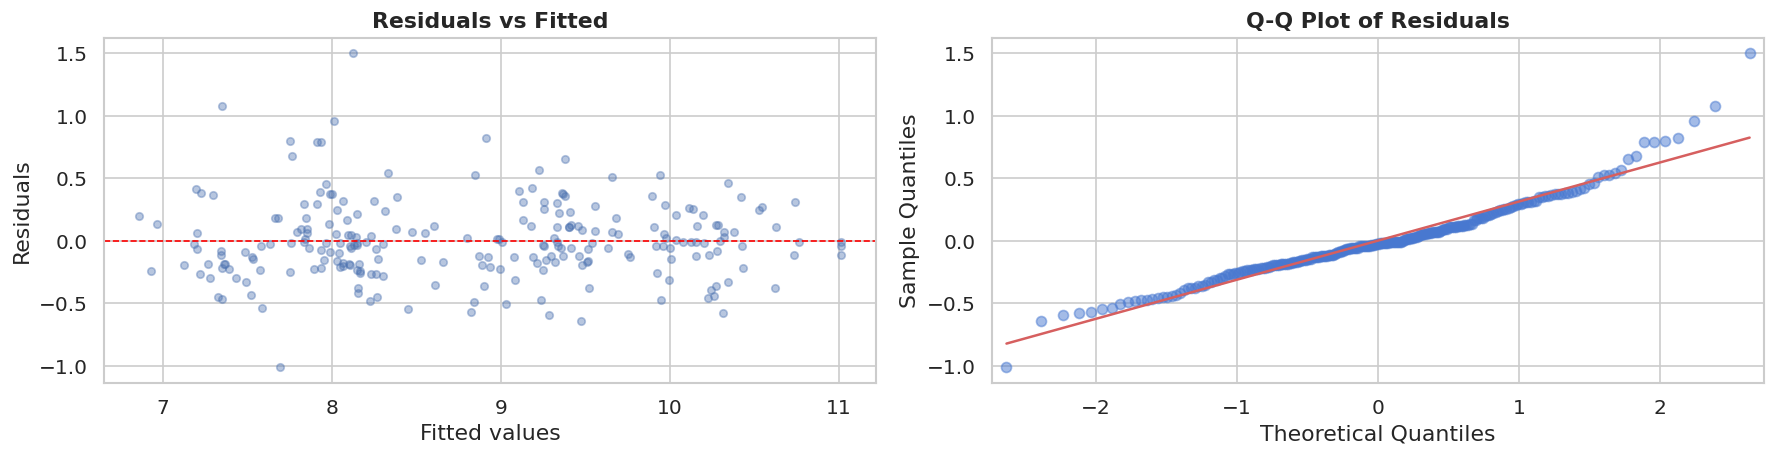

In [78]:
residuals = model_ols.resid
fitted    = model_ols.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 1. Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.4, s=20, color='#4C72B0')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted', fontweight='bold')

# 2. Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Q-Q Plot of Residuals', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_residuals_diagnostic.png', bbox_inches='tight')
plt.show()

In [79]:
# VIF — multicollinearity detection

numeric_cols = ['age', 'age_sq', "condition_score",
                'is_exotic', 'includes_box', 'discount_pct', "includes_dustbag", "includes_card_of_certificate"]

X_vif = sm.add_constant(X_train[numeric_cols])
vif_data = pd.DataFrame({
    'Variable': numeric_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i+1)
            for i in range(len(numeric_cols))]
}).sort_values('VIF', ascending=False)

print('VIF of numeric continuous variables:')
print(vif_data.round(2).to_string(index=False))
print()


VIF of numeric continuous variables:
                    Variable   VIF
                         age 13.97
                      age_sq 12.17
                includes_box  2.01
            includes_dustbag  1.83
             condition_score  1.62
                   is_exotic  1.13
includes_card_of_certificate  1.05
                discount_pct  1.03



## 8. Results Summary

In [80]:
# Save model and splits
import pickle

with open('model_ols.pkl', 'wb') as f:
    pickle.dump(model_ols, f)

# Save train/test indices for reproducibility
pd.Series(X_train.index, name='train_idx').to_csv('train_idx.csv', index=False)
pd.Series(X_test.index,  name='test_idx').to_csv('test_idx.csv',  index=False)

# Save the full feature matrix
df_dummies.to_csv('features_matrix.csv', index=True)

print('Saved: model_ols.pkl, train_idx.csv, test_idx.csv, features_matrix.csv')


Saved: model_ols.pkl, train_idx.csv, test_idx.csv, features_matrix.csv


# **PART 3: Mahine Learning Models**

In [81]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42



In [82]:
# Upload data
features   = pd.read_csv('features_matrix.csv', index_col=0)
train_idx  = pd.read_csv('train_idx.csv').squeeze()
test_idx   = pd.read_csv('test_idx.csv').squeeze()

X = features.drop(columns=['log_price'])
y = features['log_price']

X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

print(f"Train: {len(X_train)} obs | Test: {len(X_test)} obs")
print(f"Features: {X_train.shape[1]}")

# Verify split
assert len(X_train) == 236, f"ERROR: train tiene {len(X_train)} obs, esperaba 236"
assert len(X_test)  == 60,  f"ERROR: test tiene {len(X_test)} obs, esperaba 60"
print("Split verified successfully.")

Train: 236 obs | Test: 60 obs
Features: 52
Split verified successfully.


## Random Forest

In [83]:

param_grid_rf = {
    'max_depth':        [3, 4, 5],
    'min_samples_leaf': [10, 15, 20],
    'max_features':     [0.4, 0.6],
    'n_estimators':     [150]
}

rf_base = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search = GridSearchCV(
    rf_base,
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train, y_train)

print("RANDOM FOREST — GridSearchCV")
print(f"Best parameters: {rf_search.best_params_}")
print(f"CV R2 (best):       {rf_search.best_score_:.4f}")

RANDOM FOREST — GridSearchCV
Best parameters: {'max_depth': 5, 'max_features': 0.6, 'min_samples_leaf': 10, 'n_estimators': 150}
CV R2 (best):       0.7925


In [84]:
# Final model with best parameters
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

rf_final = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

y_pred_train_rf = rf_final.predict(X_train)
y_pred_test_rf  = rf_final.predict(X_test)

r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf  = r2_score(y_test,  y_pred_test_rf)
rmse_rf     = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
mae_rf      = mean_absolute_error(y_test, y_pred_test_rf)
corr_rf, _  = pearsonr(y_test, y_pred_test_rf)
gap_rf      = r2_train_rf - r2_test_rf

cv_rf = cross_val_score(rf_final, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print("RANDOM FOREST — Final Model")
print(f"R2 train:          {r2_train_rf:.4f}")
print(f"R2 test:           {r2_test_rf:.4f}")
print(f"RMSE (log):        {rmse_rf:.4f}")
print(f"MAE  (log):        {mae_rf:.4f}")
print(f"Correlación r:     {corr_rf:.4f}")
print(f"Gap:               {gap_rf:.4f}")
print(f"CV R2 (mean):      {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

RANDOM FOREST — Final Model
R2 train:          0.8516
R2 test:           0.7760
RMSE (log):        0.5060
MAE  (log):        0.3836
Correlación r:     0.8841
Gap:               0.0756
CV R2 (mean):      0.7925 ± 0.0456


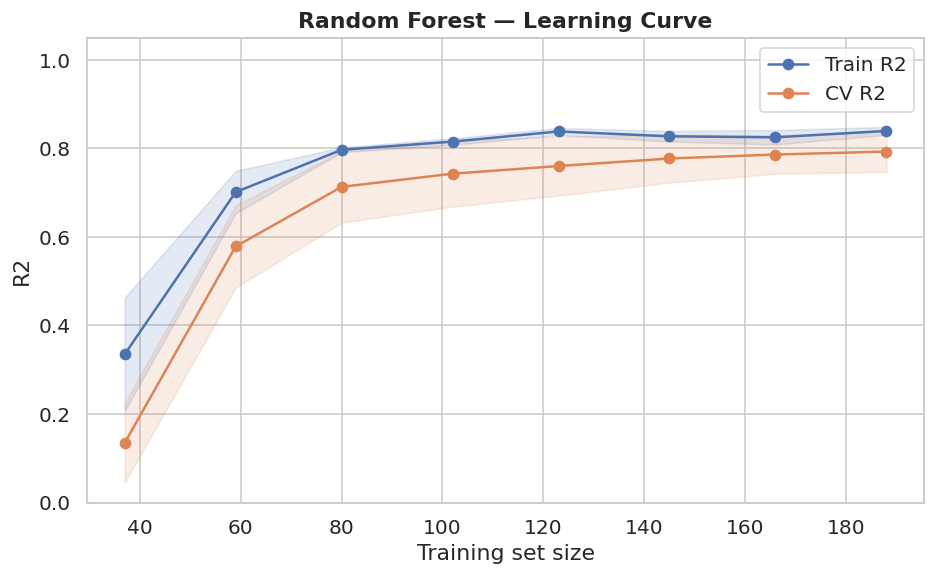

Gap train-CV at full size: 0.0466


In [85]:
# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    rf_final, X_train, y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1,
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#4C72B0', label='Train R2')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#4C72B0')
ax.plot(train_sizes, val_mean, 'o-', color='#DD8452', label='CV R2')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#DD8452')
ax.set_xlabel('Training set size')
ax.set_ylabel('R2')
ax.set_title('Random Forest — Learning Curve', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('fig_rf_learning_curve.png', bbox_inches='tight')
plt.show()

final_gap = train_mean[-1] - val_mean[-1]
print(f"Gap train-CV at full size: {final_gap:.4f}")

## XGBoost

In [86]:

from xgboost import XGBRegressor


param_grid_xgb_v1 = {
    'max_depth':        [3, 4],
    'min_child_weight': [10, 15, 20],
    'reg_lambda':       [5, 10],
    'subsample':        [0.6, 0.8],
    'n_estimators':     [100, 150]
}

xgb_base_v1 = XGBRegressor(
    learning_rate=0.05,
    colsample_bytree=0.6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    objective='reg:squarederror'
)

xgb_search_v1 = GridSearchCV(
    xgb_base_v1,
    param_grid_xgb_v1,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

xgb_search_v1.fit(X_train, y_train)

print("XGBOOST v1 — GridSearchCV")
print(f"Best parameters: {xgb_search_v1.best_params_}")
print(f"CV R2 (best):       {xgb_search_v1.best_score_:.4f}")

XGBOOST v1 — GridSearchCV
Best parameters: {'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 150, 'reg_lambda': 5, 'subsample': 0.8}
CV R2 (best):       0.8639


In [87]:
# XGBoost v1 — Final Model
xgb_final_v1 = XGBRegressor(
    **xgb_search_v1.best_params_,
    learning_rate=0.05,
    colsample_bytree=0.6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    objective='reg:squarederror'
)
xgb_final_v1.fit(X_train, y_train)

y_pred_train_xgb_v1 = xgb_final_v1.predict(X_train)
y_pred_test_xgb_v1  = xgb_final_v1.predict(X_test)

r2_train_xgb_v1 = r2_score(y_train, y_pred_train_xgb_v1)
r2_test_xgb_v1  = r2_score(y_test,  y_pred_test_xgb_v1)
rmse_xgb_v1     = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb_v1))
mae_xgb_v1      = mean_absolute_error(y_test, y_pred_test_xgb_v1)
corr_xgb_v1, _  = pearsonr(y_test, y_pred_test_xgb_v1)
gap_xgb_v1      = r2_train_xgb_v1 - r2_test_xgb_v1
cv_xgb_v1       = cross_val_score(xgb_final_v1, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print("XGBOOST v1 — Final Model")
print(f"R2 train:          {r2_train_xgb_v1:.4f}")
print(f"R2 test:           {r2_test_xgb_v1:.4f}")
print(f"RMSE (log):        {rmse_xgb_v1:.4f}")
print(f"MAE  (log):        {mae_xgb_v1:.4f}")
print(f"Correlación r:     {corr_xgb_v1:.4f}")
print(f"Gap:               {gap_xgb_v1:.4f}")
print(f"CV R2 (mean):      {cv_xgb_v1.mean():.4f} ± {cv_xgb_v1.std():.4f}")

XGBOOST v1 — Final Model
R2 train:          0.9342
R2 test:           0.7986
RMSE (log):        0.4799
MAE  (log):        0.3650
Correlación r:     0.8944
Gap:               0.1357
CV R2 (mean):      0.8639 ± 0.0359


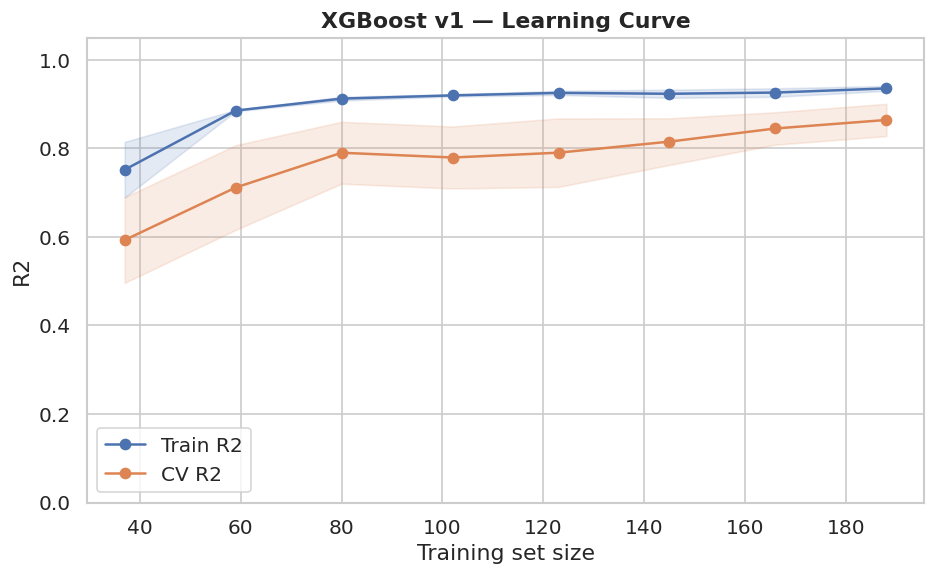

Gap train-CV at full size: 0.0712


In [88]:
# XGBoost v1 — Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    xgb_final_v1, X_train, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1, random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#4C72B0', label='Train R2')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#4C72B0')
ax.plot(train_sizes, val_mean, 'o-', color='#DD8452', label='CV R2')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#DD8452')
ax.set_xlabel('Training set size')
ax.set_ylabel('R2')
ax.set_title('XGBoost v1 — Learning Curve', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('fig_xgb_v1_learning_curve.png', bbox_inches='tight')
plt.show()

print(f"Gap train-CV at full size: {train_mean[-1] - val_mean[-1]:.4f}")

In [89]:
# XGBoost — final specification (max_depth=3)
# max_depth reduced to 3 to control overfitting

param_grid_xgb_final = {
    'max_depth':        [3],
    'min_child_weight': [10, 15],
    'reg_lambda':       [5, 10],
    'subsample':        [0.6, 0.8],
    'n_estimators':     [100, 150]
}

xgb_base_final = XGBRegressor(
    learning_rate=0.05,
    colsample_bytree=0.6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    objective='reg:squarederror'
)

xgb_search_final = GridSearchCV(
    xgb_base_final,
    param_grid_xgb_final,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

xgb_search_final.fit(X_train, y_train)

print("XGBOOST — GridSearchCV (final model)")
print(f"Best parameters: {xgb_search_final.best_params_}")
print(f"CV R2 (best):       {xgb_search_final.best_score_:.4f}")

XGBOOST — GridSearchCV (final model)
Best parameters: {'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 150, 'reg_lambda': 5, 'subsample': 0.8}
CV R2 (best):       0.8613


In [90]:
# XGBoost — Final Model
xgb_final = XGBRegressor(
    **xgb_search_final.best_params_,
    learning_rate=0.05,
    colsample_bytree=0.6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    objective='reg:squarederror'
)
xgb_final.fit(X_train, y_train)

y_pred_train_xgb = xgb_final.predict(X_train)
y_pred_test_xgb  = xgb_final.predict(X_test)

r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
r2_test_xgb  = r2_score(y_test,  y_pred_test_xgb)
rmse_xgb     = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))
mae_xgb      = mean_absolute_error(y_test, y_pred_test_xgb)
corr_xgb, _  = pearsonr(y_test, y_pred_test_xgb)
gap_xgb      = r2_train_xgb - r2_test_xgb
cv_xgb       = cross_val_score(xgb_final, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print("XGBOOST — Final Model")
print(f"R2 train:          {r2_train_xgb:.4f}")
print(f"R2 test:           {r2_test_xgb:.4f}")
print(f"RMSE (log):        {rmse_xgb:.4f}")
print(f"MAE  (log):        {mae_xgb:.4f}")
print(f"Correlación r:     {corr_xgb:.4f}")
print(f"Gap:               {gap_xgb:.4f}")
print(f"CV R2 (mean):      {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")

XGBOOST — Final Model
R2 train:          0.9234
R2 test:           0.8023
RMSE (log):        0.4754
MAE  (log):        0.3617
Correlación r:     0.8971
Gap:               0.1211
CV R2 (mean):      0.8613 ± 0.0364


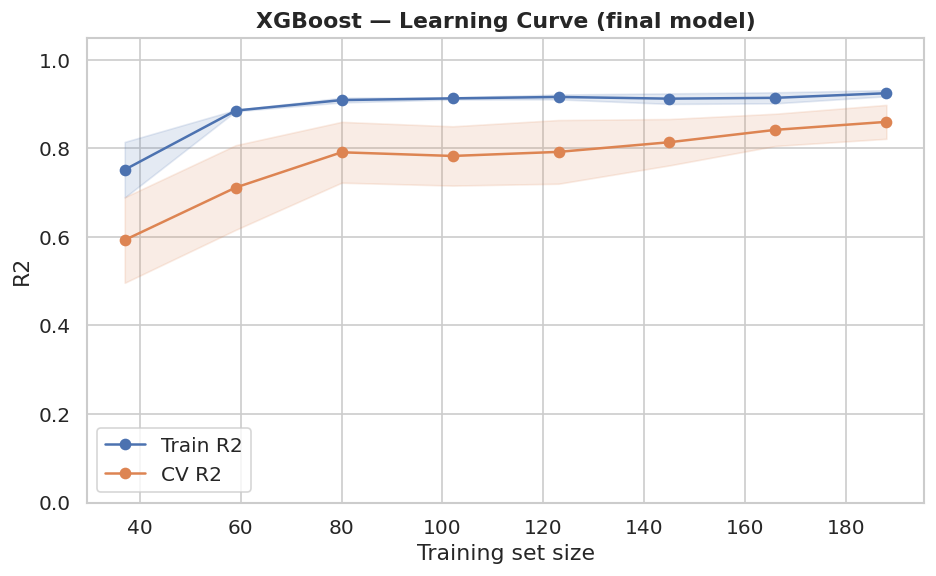

Gap train-CV at full size: 0.0647


In [91]:
#XGBoost — Learning Curve (final model)
train_sizes, train_scores, val_scores = learning_curve(
    xgb_final, X_train, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1, random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#4C72B0', label='Train R2')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#4C72B0')
ax.plot(train_sizes, val_mean, 'o-', color='#DD8452', label='CV R2')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#DD8452')
ax.set_xlabel('Training set size')
ax.set_ylabel('R2')
ax.set_title('XGBoost — Learning Curve (final model)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('fig_xgb_learning_curve.png', bbox_inches='tight')
plt.show()

print(f"Gap train-CV at full size: {train_mean[-1] - val_mean[-1]:.4f}")

In [92]:

# FINAL COMPARISON: OLS vs RF vs XGBOOST

from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

# OLS metrics
r2_test_ols  = r2_score(y_test, y_pred_test)
rmse_ols     = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_ols      = mean_absolute_error(y_test, y_pred_test)
corr_ols, _  = pearsonr(y_test, y_pred_test)
gap_ols      = model_ols.rsquared - r2_test_ols

print("FINAL MODEL COMPARISON\n")
print(f"{'Metric':<20} {'OLS':>10} {'Random Forest':>15} {'XGBoost':>10}")
print("-" * 58)
print(f"{'R2 train':<20} {model_ols.rsquared:>10.4f} {r2_train_rf:>15.4f} {r2_train_xgb:>10.4f}")
print(f"{'R2 test':<20} {r2_test_ols:>10.4f} {r2_test_rf:>15.4f} {r2_test_xgb:>10.4f}")
print(f"{'RMSE (log)':<20} {rmse_ols:>10.4f} {rmse_rf:>15.4f} {rmse_xgb:>10.4f}")
print(f"{'MAE (log)':<20} {mae_ols:>10.4f} {mae_rf:>15.4f} {mae_xgb:>10.4f}")
print(f"{'Correlación r':<20} {corr_ols:>10.4f} {corr_rf:>15.4f} {corr_xgb:>10.4f}")
print(f"{'Gap train-test':<20} {gap_ols:>10.4f} {gap_rf:>15.4f} {gap_xgb:>10.4f}")
print(f"{'CV R2':<20} {'N/A':>10} {cv_rf.mean():>15.4f} {cv_xgb.mean():>10.4f}")

FINAL MODEL COMPARISON

Metric                      OLS   Random Forest    XGBoost
----------------------------------------------------------
R2 train                 0.9163          0.8516     0.9234
R2 test                  0.7704          0.7760     0.8023
RMSE (log)               0.5123          0.5060     0.4754
MAE (log)                0.3968          0.3836     0.3617
Correlación r            0.8783          0.8841     0.8971
Gap train-test           0.1459          0.0756     0.1211
CV R2                       N/A          0.7925     0.8613


# **PART 4: SHAP Values**

SHAP values shape (train): (236, 52)
SHAP values shape (test):  (60, 52)


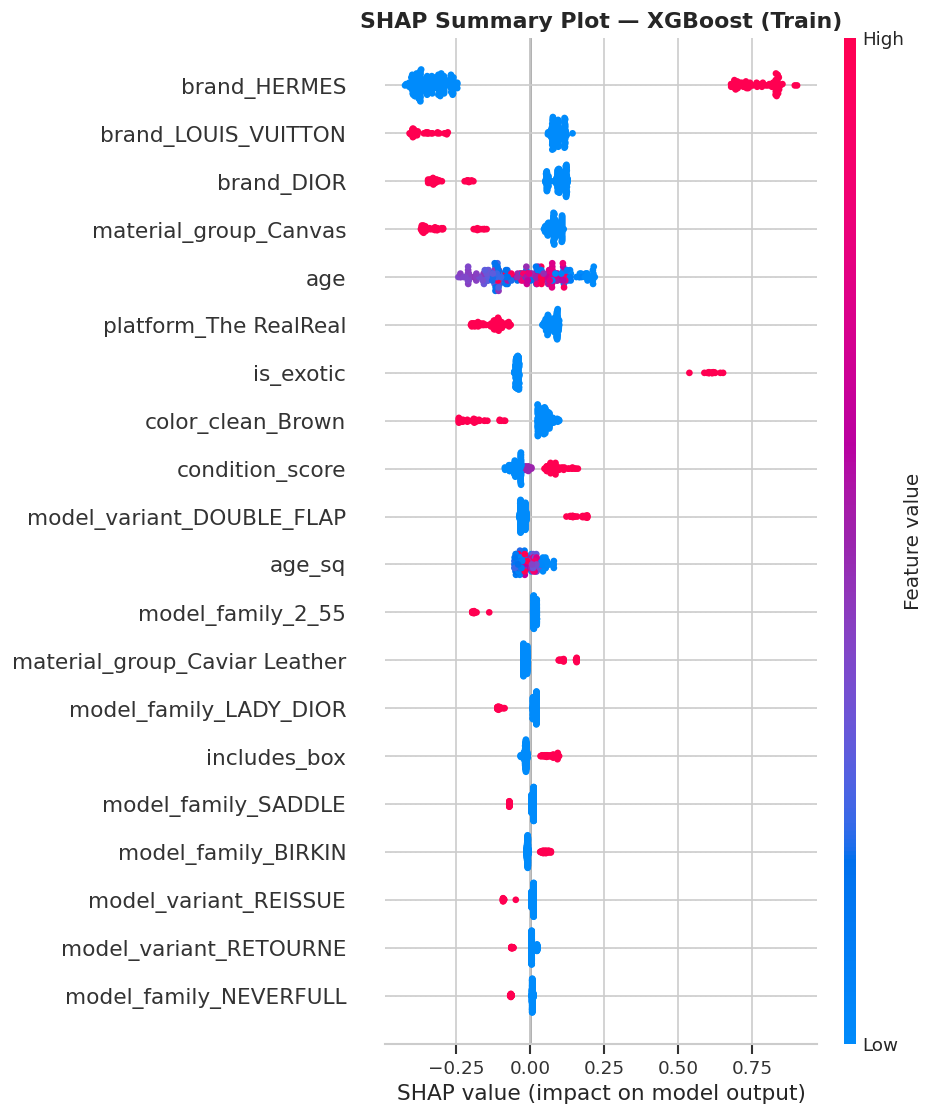

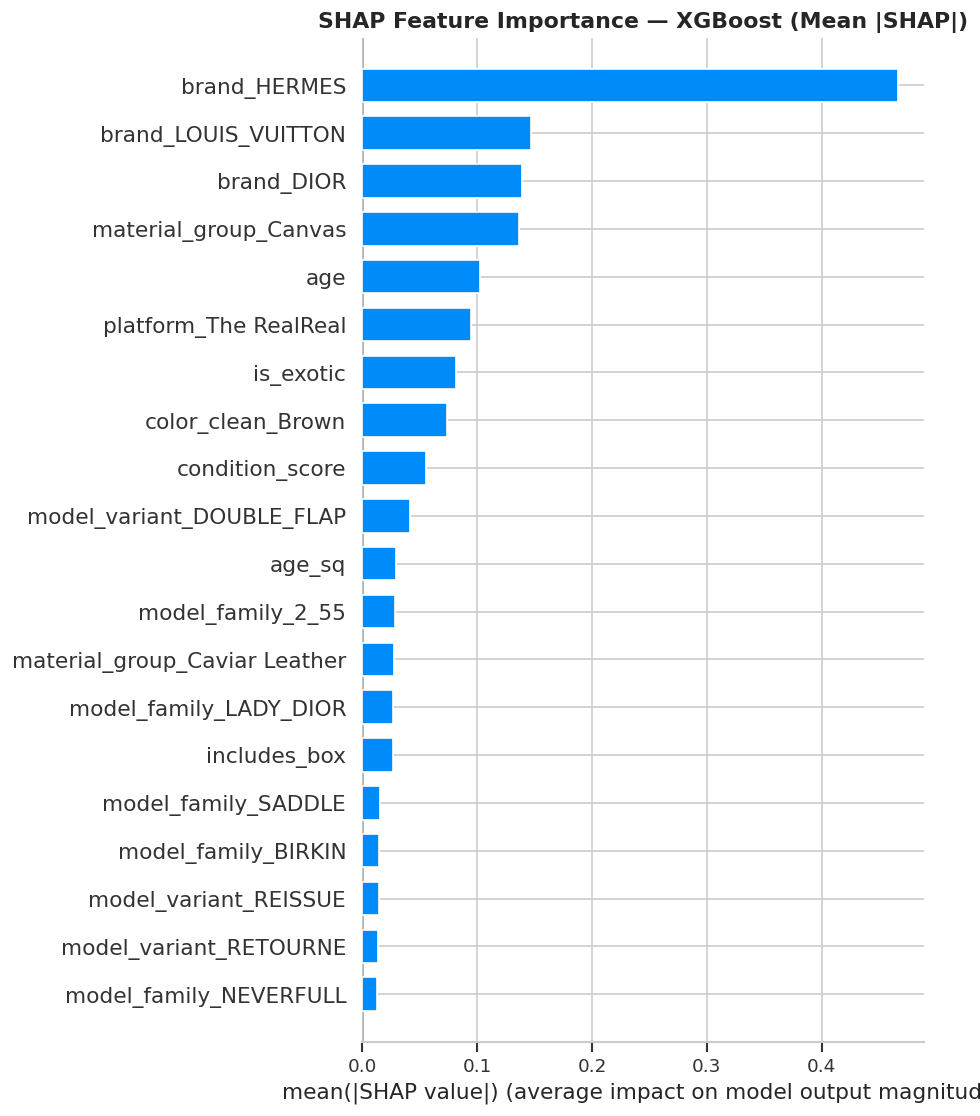

In [93]:

import shap
shap.initjs()

# SHAP TreeExplainer

explainer = shap.TreeExplainer(xgb_final)
shap_values_train = explainer.shap_values(X_train)
shap_values_test  = explainer.shap_values(X_test)

print(f"SHAP values shape (train): {shap_values_train.shape}")
print(f"SHAP values shape (test):  {shap_values_test.shape}")


# Global Feature Importance — Beeswarm Plot (Summary Plot)

plt.figure()
shap.summary_plot(
    shap_values_train,
    X_train,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot — XGBoost (Train)", fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_summary.png', bbox_inches='tight')
plt.show()


# Global Feature Importance — Bar Plot (Mean |SHAP|)

plt.figure()
shap.summary_plot(
    shap_values_train,
    X_train,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance — XGBoost (Mean |SHAP|)", fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_bar.png', bbox_inches='tight')
plt.show()


In [94]:
shap_importance = pd.DataFrame({
    'feature': X_train.columns,
    'mean_shap': np.abs(shap_values_train).mean(axis=0)
}).sort_values('mean_shap', ascending=False)
print(shap_importance.head(20))

                          feature  mean_shap
9                    brand_HERMES   0.466019
10            brand_LOUIS_VUITTON   0.147102
8                      brand_DIOR   0.139515
19          material_group_Canvas   0.136160
0                             age   0.102736
45          platform_The RealReal   0.094931
3                       is_exotic   0.081769
34              color_clean_Brown   0.073910
2                 condition_score   0.055648
46      model_variant_DOUBLE_FLAP   0.041438
1                          age_sq   0.029465
11              model_family_2_55   0.028996
20  material_group_Caviar Leather   0.027406
14         model_family_LADY_DIOR   0.027333
4                    includes_box   0.026709
16            model_family_SADDLE   0.015412
12            model_family_BIRKIN   0.014964
49          model_variant_REISSUE   0.014318
50         model_variant_RETOURNE   0.013461
15         model_family_NEVERFULL   0.012844


<Figure size 768x576 with 0 Axes>

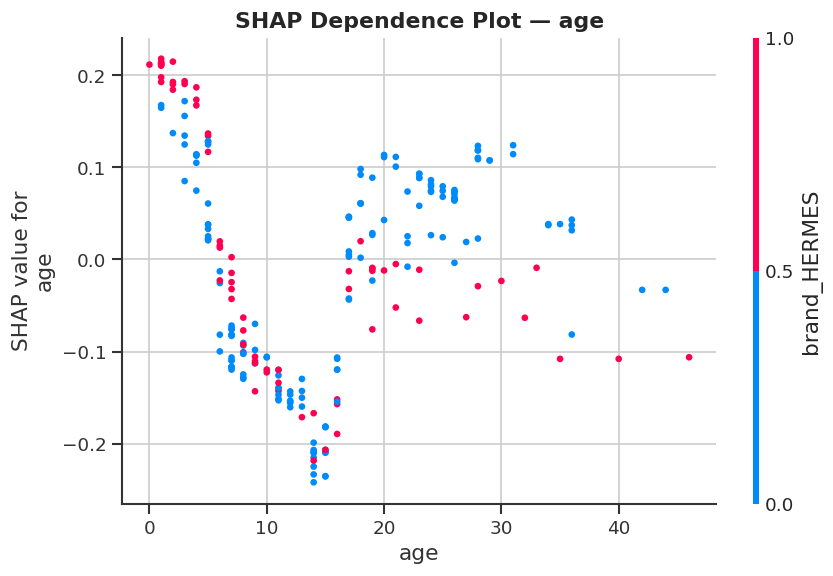

<Figure size 768x576 with 0 Axes>

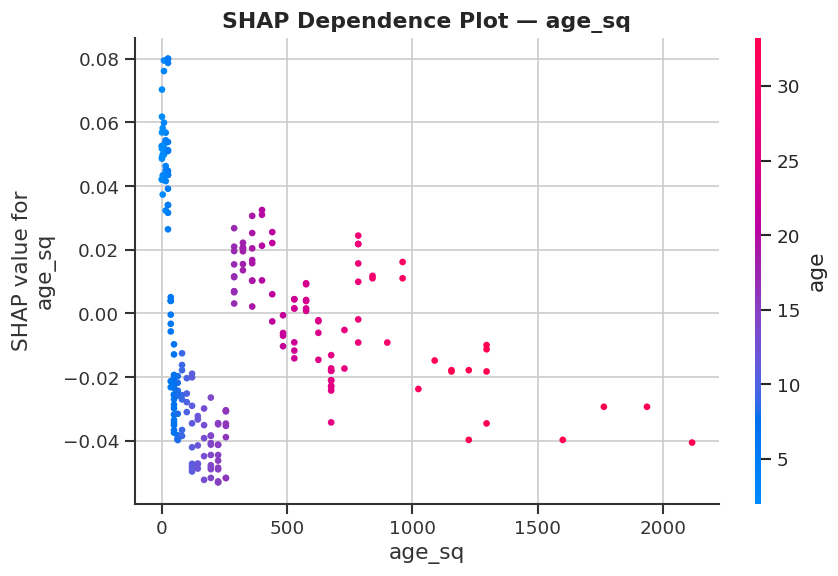

<Figure size 768x576 with 0 Axes>

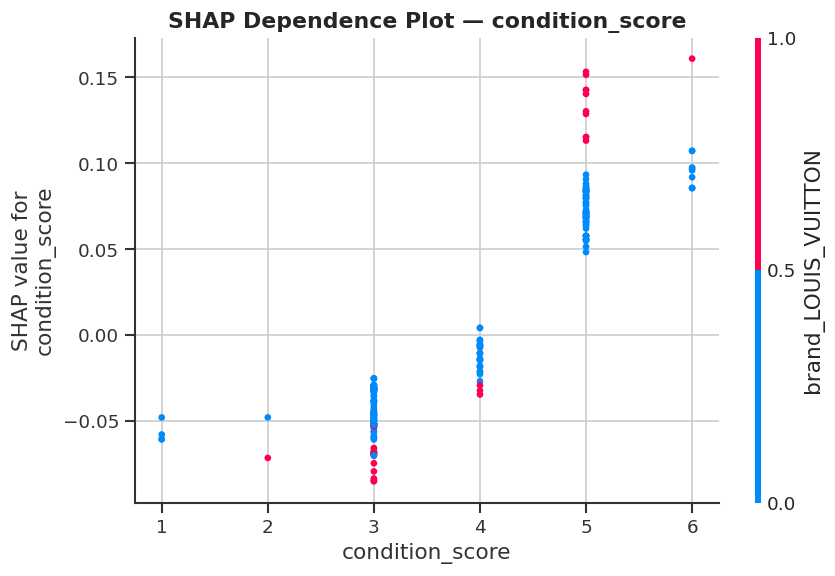

In [95]:
# Dependence Plots — Top 3 variables

continuous_vars = ['age', 'age_sq', 'condition_score']

for var in continuous_vars:
    plt.figure()
    shap.dependence_plot(
        var,
        shap_values_train,
        X_train,
        show=False
    )
    plt.title(f"SHAP Dependence Plot — {var}", fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'fig_shap_dep_{var}.png', bbox_inches='tight')
    plt.show()

# **PART 5: Retail Prices Comparison**

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')


Load Data

In [111]:
resale_raw = pd.read_csv('resale_listings.csv', sep=';', on_bad_lines='skip')
retail = pd.read_excel('Retail_dataset.xlsx')

print(f"Resale listings loaded: {len(resale_raw)} observations")
print(f"Retail records loaded:  {len(retail)} observations across {retail['product_key_core'].nunique()} model-size combinations")

Resale listings loaded: 302 observations
Retail records loaded:  86 observations across 28 model-size combinations


Prepare Resale Data

In [112]:
resale = resale_raw.copy()
resale['price_current'] = pd.to_numeric(resale['price_current'], errors='coerce')
resale = resale[resale['price_current'].notna()]

print(f"Resale listings: {len(resale)} observations")

Resale listings: 302 observations


Current Retail Prices (2026)

In [113]:
retail_2026 = (
    retail[retail['year_recorded'] == 2026]
    [['product_key_core', 'retail_price_EUR', 'source']]
    .copy()
    .rename(columns={'product_key_core': 'retail_key',
                     'retail_price_EUR': 'retail_price_2026'})
)

print(f"Retail 2026 reference prices: {len(retail_2026)} model-size combinations")
print(retail_2026.to_string(index=False))

Retail 2026 reference prices: 28 model-size combinations
                          retail_key  retail_price_2026        source
                     CHANEL_2_55_224               4950        Chanel
                     CHANEL_2_55_225              10300        Chanel
                     CHANEL_2_55_226              11100        Chanel
                     CHANEL_2_55_227              13100        Chanel
     CHANEL_CLASSIC_FLAP_MINI_SQUARE               4750        Chanel
CHANEL_CLASSIC_FLAP_MINI_RECTANGULAR               4950        Chanel
           CHANEL_CLASSIC_FLAP_SMALL               9900        Chanel
          CHANEL_CLASSIC_FLAP_MEDIUM              10300        Chanel
           CHANEL_CLASSIC_FLAP_JUMBO              11100        Chanel
            CHANEL_CLASSIC_FLAP_MAXI              11700        Chanel
                 DIOR_LADY_DIOR_MINI               4700          Dior
               DIOR_LADY_DIOR_MEDIUM               5900          Dior
                    DIOR_SADDLE_M

 Resale/Retail Matching

In [114]:

results = []

for _, row in retail_2026.iterrows():
    retail_key   = row['retail_key']
    retail_price = row['retail_price_2026']
    source       = row['source']

    matches = resale[resale['product_key_core'].str.startswith(retail_key)]

    if len(matches) == 0:
        continue

    n             = len(matches)
    median_resale = matches['price_current'].median()
    mean_resale   = matches['price_current'].mean()
    std_resale    = matches['price_current'].std()
    ratio         = median_resale / retail_price

    brand = retail_key.split('_')[0].capitalize()
    if retail_key.startswith('LOUIS'):  brand = 'Louis Vuitton'
    elif retail_key.startswith('HERMES'): brand = 'Hermes'

    results.append({
        'retail_key':          retail_key,
        'brand':               brand,
        'retail_price_2026':   retail_price,
        'median_resale_EUR':   round(median_resale),
        'mean_resale_EUR':     round(mean_resale),
        'std_resale_EUR':      round(std_resale) if n > 1 else None,
        'n_listings':          n,
        'resale_retail_ratio': round(ratio, 3),
        'retail_source':       source
    })

df_ratios = pd.DataFrame(results).sort_values(['brand', 'resale_retail_ratio'],
                                               ascending=[True, False])

print("Resale-to-Retail Ratios")
print(df_ratios[['retail_key', 'retail_price_2026', 'median_resale_EUR',
                  'n_listings', 'resale_retail_ratio']].to_string(index=False))

Resale-to-Retail Ratios
                          retail_key  retail_price_2026  median_resale_EUR  n_listings  resale_retail_ratio
     CHANEL_CLASSIC_FLAP_MINI_SQUARE               4750              10045          15                2.115
           CHANEL_CLASSIC_FLAP_SMALL               9900              11748          11                1.187
CHANEL_CLASSIC_FLAP_MINI_RECTANGULAR               4950               5748           3                1.161
          CHANEL_CLASSIC_FLAP_MEDIUM              10300               9649          31                0.937
           CHANEL_CLASSIC_FLAP_JUMBO              11100              10153          10                0.915
                     CHANEL_2_55_224               4950               3836           6                0.775
                     CHANEL_2_55_225              10300               4304           4                0.418
                     CHANEL_2_55_227              13100               3229           7                0.246
    

CAGR Analysis

In [117]:
cagr_results = []

for key in retail['product_key_core'].unique():
    sub = retail[retail['product_key_core'] == key].sort_values('year_recorded')
    if len(sub) < 2:
        continue

    start = sub.iloc[0]
    end   = sub.iloc[-1]
    years = end['year_recorded'] - start['year_recorded']

    if years == 0 or start['retail_price_EUR'] == end['retail_price_EUR']:
        continue

    cagr         = (end['retail_price_EUR'] / start['retail_price_EUR']) ** (1 / years) - 1
    total_return = end['retail_price_EUR'] / start['retail_price_EUR'] - 1

    brand = key.split('_')[0].capitalize()
    if key.startswith('LOUIS'):  brand = 'Louis Vuitton'
    elif key.startswith('HERMES'): brand = 'Hermes'

    cagr_results.append({
        'model':              key,
        'brand':              brand,
        'start_year':         int(start['year_recorded']),
        'end_year':           int(end['year_recorded']),
        'start_price_EUR':    int(start['retail_price_EUR']),
        'end_price_EUR':      int(end['retail_price_EUR']),
        'total_increase_pct': round(total_return * 100, 1),
        'retail_CAGR_pct':    round(cagr * 100, 2)
    })

df_cagr = pd.DataFrame(cagr_results).sort_values('retail_CAGR_pct', ascending=False)

print("Retail Price CAGR")
print(df_cagr[['model', 'start_year', 'end_year', 'start_price_EUR',
                'end_price_EUR', 'total_increase_pct', 'retail_CAGR_pct']].to_string(index=False))

Retail Price CAGR
                     model  start_year  end_year  start_price_EUR  end_price_EUR  total_increase_pct  retail_CAGR_pct
           CHANEL_2_55_225        2020      2026             6050          10300                70.2             9.27
 CHANEL_CLASSIC_FLAP_JUMBO        2020      2026             6600          11100                68.2             9.05
           CHANEL_2_55_226        2020      2026             6600          11100                68.2             9.05
  CHANEL_CLASSIC_FLAP_MAXI        2020      2026             7100          11700                64.8             8.68
 CHANEL_CLASSIC_FLAP_SMALL        2022      2026             7750           9900                27.7             6.31
   LOUIS_VUITTON_SPEEDY_20        2022      2026             1500           1900                26.7             6.09
           CHANEL_2_55_224        2022      2026             4000           4950                23.8             5.47
 LOUIS_VUITTON_SPEEDY_NANO        2022

Figure Resale/Retail Ratio

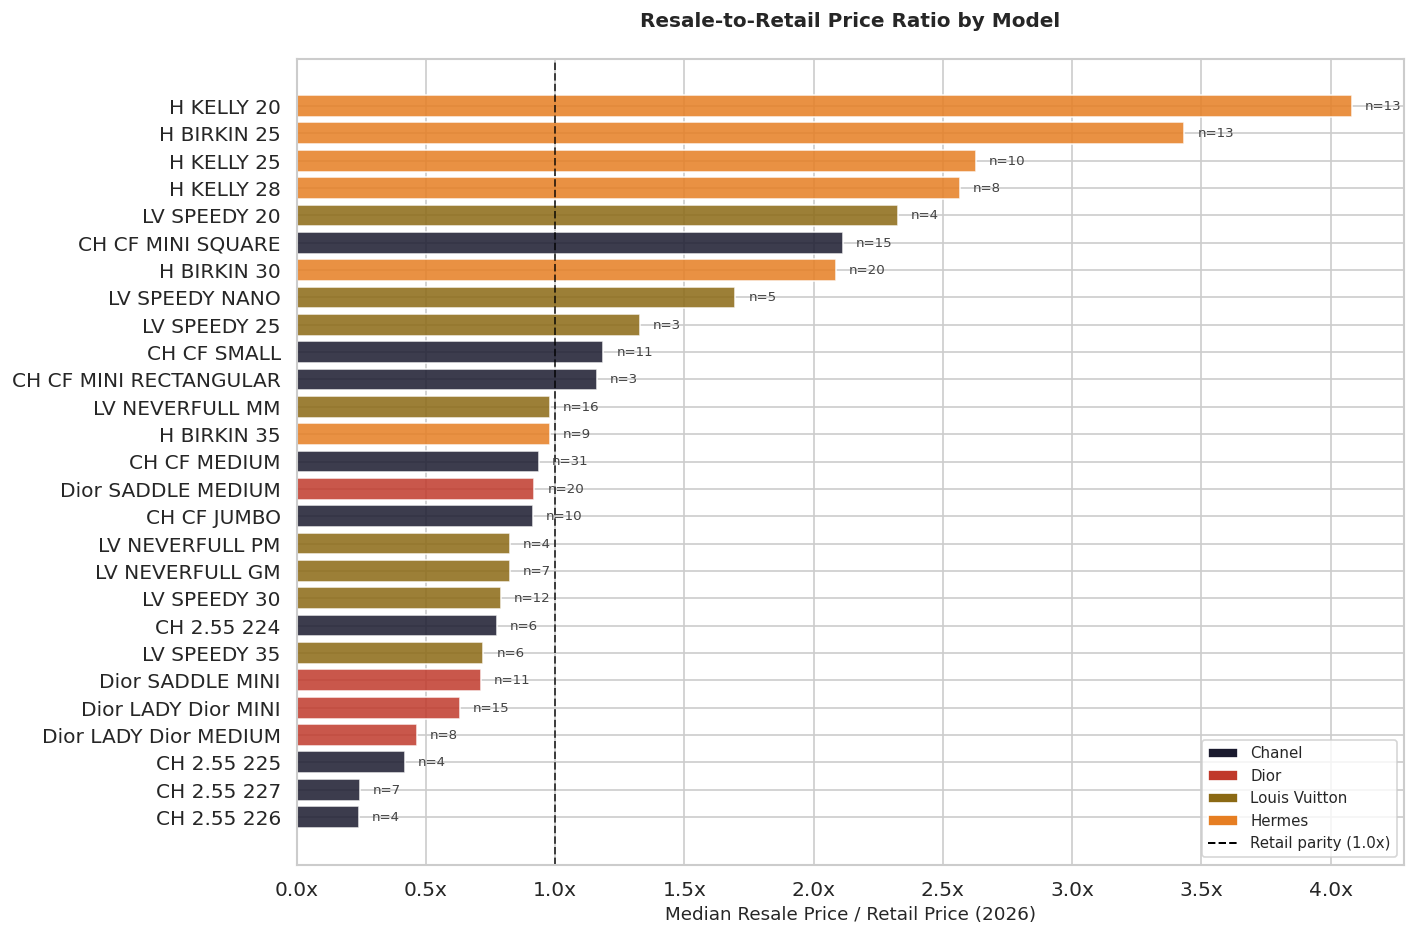

In [120]:
from matplotlib.patches import Patch

brand_colors = {
    'Chanel':        '#1a1a2e',
    'Dior':          '#c0392b',
    'Louis Vuitton': '#8B6914',
    'Hermes':        '#e67e22'
}

df_plot = df_ratios.sort_values('resale_retail_ratio', ascending=True).copy()
df_plot['label'] = (df_plot['retail_key']
    .str.replace('CHANEL_CLASSIC_FLAP_', 'CH CF ')
    .str.replace('CHANEL_2_55_', 'CH 2.55 ')
    .str.replace('DIOR_', 'Dior ')
    .str.replace('LOUIS_VUITTON_', 'LV ')
    .str.replace('HERMES_', 'H ')
    .str.replace('_', ' '))

fig, ax = plt.subplots(figsize=(12, 8))
colors = [brand_colors.get(b, '#555') for b in df_plot['brand']]
ax.barh(df_plot['label'], df_plot['resale_retail_ratio'], color=colors, alpha=0.85)
ax.axvline(x=1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)

for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.text(row['resale_retail_ratio'] + 0.05, i,
            f"n={row['n_listings']}", va='center', fontsize=8, color='#444')

legend_elements = [Patch(facecolor=c, label=b) for b, c in brand_colors.items()]
legend_elements.append(plt.Line2D([0], [0], color='black', linewidth=1.2,
                                   linestyle='--', label='Retail parity (1.0x)'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_xlabel('Median Resale Price / Retail Price (2026)', fontsize=11)
ax.set_title('Resale-to-Retail Price Ratio by Model\n',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fx'))
plt.tight_layout()
plt.savefig('fig_retail_resale_ratio.png', bbox_inches='tight', dpi=150)
plt.show()

Figure Hermès Birkin Evolution

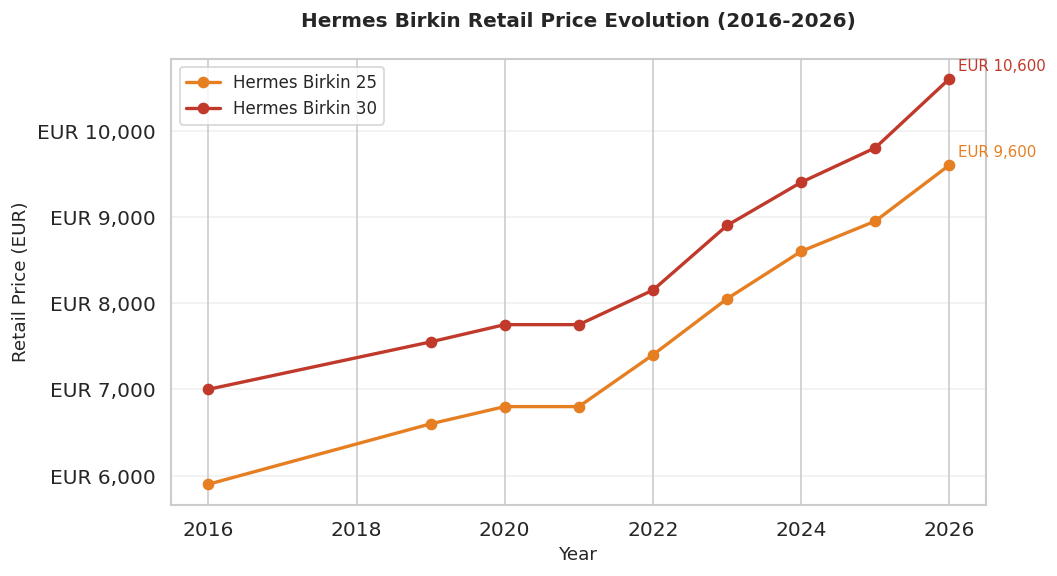

In [122]:
fig, ax = plt.subplots(figsize=(9, 5))

for model, color, label in [
    ('HERMES_BIRKIN_25', '#e67e22', 'Hermes Birkin 25'),
    ('HERMES_BIRKIN_30', '#c0392b', 'Hermes Birkin 30')
]:
    sub = retail[retail['product_key_core'] == model].sort_values('year_recorded')
    ax.plot(sub['year_recorded'], sub['retail_price_EUR'],
            marker='o', linewidth=2, color=color, label=label)
    last = sub.iloc[-1]
    ax.annotate(f"EUR {int(last['retail_price_EUR']):,}",
                xy=(last['year_recorded'], last['retail_price_EUR']),
                xytext=(5, 5), textcoords='offset points', fontsize=9, color=color)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Retail Price (EUR)', fontsize=11)
ax.set_title("Hermes Birkin Retail Price Evolution (2016-2026)\n",
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'EUR {int(x):,}'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_hermes_retail_evolution.png', bbox_inches='tight', dpi=150)
plt.show()